## 6.2.2 BaselineCNN 正式训练

本步骤基于前序完成的 EuroSAT RGB 分层数据集、图像增强、ImageNet 标准化和统一训练超参数，对基础卷积神经网络 BaselineCNN 进行正式训练。

训练过程使用训练集完成参数更新，使用验证集计算 Top-1 Accuracy、Top-3 Accuracy、Macro Precision、Macro Recall、Macro F1 和 Weighted F1，并以验证集 Macro-F1 作为最佳模型选择指标。

本 Notebook 支持：

- AutoDL 单卡 NVIDIA GPU 自动检测；
- CUDA 混合精度训练；
- DataLoader 多进程读取与页锁定内存；
- 每批次训练进度显示；
- 学习率自动衰减；
- 最佳模型与最近模型检查点保存；
- 中断后的断点续训；
- 训练曲线、混淆矩阵和分类指标输出。

In [1]:
# ==========================================
# 6.2.2 基础导入、服务器环境与项目路径
# AutoDL RTX 4090D兼容版
# ==========================================

# 必须在导入NumPy和PyTorch之前设置
import os


# ------------------------------
# Linux服务器线程配置
# ------------------------------
SERVER_CPU_COUNT = (
    os.cpu_count()
    if os.cpu_count() is not None
    else 4
)

SERVER_CPU_THREADS = min(
    8,
    max(
        2,
        SERVER_CPU_COUNT // 2
    )
)


os.environ[
    "OMP_NUM_THREADS"
] = str(
    SERVER_CPU_THREADS
)

os.environ[
    "MKL_NUM_THREADS"
] = str(
    SERVER_CPU_THREADS
)

os.environ[
    "OPENBLAS_NUM_THREADS"
] = str(
    SERVER_CPU_THREADS
)

os.environ[
    "NUMEXPR_NUM_THREADS"
] = str(
    SERVER_CPU_THREADS
)

os.environ.setdefault(
    "PYTHONHASHSEED",
    "42"
)

os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8"
)

os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True"
)


# ------------------------------
# 常用库导入
# ------------------------------
import sys
import json
import math
import time
import random
import hashlib
import platform
import warnings

from pathlib import Path
from contextlib import nullcontext
from datetime import datetime


import numpy as np
import pandas as pd

from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import torch
import torch.nn as nn
import torchvision

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms

from torchvision.transforms import (
    InterpolationMode
)

from IPython.display import display


warnings.filterwarnings(
    "default"
)


# ------------------------------
# 可选进度条
# ------------------------------
try:

    from tqdm.auto import tqdm

    TQDM_AVAILABLE = True

except ImportError:

    TQDM_AVAILABLE = False


# ------------------------------
# PyTorch CPU辅助线程
# ------------------------------
torch.set_num_threads(
    SERVER_CPU_THREADS
)

try:

    torch.set_num_interop_threads(
        1
    )

except RuntimeError:

    pass


# ------------------------------
# 项目根目录自动定位
# ------------------------------
PROJECT_ROOT_OVERRIDE = None


def is_project_root(
    path
):
    """
    判断给定目录是否为当前课设项目根目录。
    """

    path = Path(
        path
    )

    required_names = [
        "EuroSAT_RGB",
        "models",
        "notebooks",
        "results"
    ]

    return all(
        (
            path
            / required_name
        ).exists()
        for required_name
        in required_names
    )


def find_project_root():
    """
    兼容本地、AutoDL临时数据盘和AutoDL网盘目录。
    """

    if PROJECT_ROOT_OVERRIDE is not None:

        override_path = Path(
            PROJECT_ROOT_OVERRIDE
        ).expanduser().resolve()

        if not is_project_root(
            override_path
        ):

            raise FileNotFoundError(
                "PROJECT_ROOT_OVERRIDE指向的目录"
                "不是完整项目根目录。"
            )

        return override_path


    current_path = Path.cwd().resolve()

    for candidate_path in [
        current_path,
        *current_path.parents
    ]:

        if is_project_root(
            candidate_path
        ):

            return candidate_path


    search_base_paths = [
        Path(
            "/root/autodl-tmp"
        ),
        Path(
            "/root/autodl-fs"
        ),
        Path(
            "/workspace"
        ),
        Path(
            "/home"
        )
    ]


    for base_path in search_base_paths:

        if not base_path.exists():

            continue

        candidate_paths = [
            base_path,
            *base_path.glob(
                "*"
            ),
            *base_path.glob(
                "*/*"
            )
        ]

        for candidate_path in candidate_paths:

            if (
                candidate_path.is_dir()
                and is_project_root(
                    candidate_path
                )
            ):

                return (
                    candidate_path
                    .resolve()
                )


    raise FileNotFoundError(
        "未找到项目根目录。\n"
        "请确认上传并解压后的目录中同时包含：\n"
        "EuroSAT_RGB、models、notebooks和results。\n"
        "如仍无法定位，请在Cell 2中手动设置"
        "PROJECT_ROOT_OVERRIDE。"
    )


PROJECT_ROOT = find_project_root()


# ------------------------------
# 项目目录
# ------------------------------
EUROSAT_ROOT = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

DATA_DIR = (
    EUROSAT_ROOT
    / "data"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

NOTEBOOKS_DIR = (
    PROJECT_ROOT
    / "notebooks"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


BASELINE_MODEL_DIR = (
    MODELS_DIR
    / "baseline_cnn"
)

BASELINE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STEP_OUTPUT_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.2.2_BaselineCNN正式训练"
)

STEP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------
# 前序统一配置路径
# ------------------------------
RUNTIME_CONFIG_PATH = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.1_统一训练环境与随机性控制"
    / "07_统一训练环境配置.json"
)

EVALUATION_CONFIG_PATH = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.2_损失函数与评价指标"
    / "10_统一评价配置.json"
)

TRAINING_CONFIG_PATH = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.3_训练超参数与优化器配置"
    / "09_统一训练超参数配置.json"
)


# ------------------------------
# 中文字体配置
# ------------------------------
font_candidates = [
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "Source Han Sans CN",
    "WenQuanYi Micro Hei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS"
]

available_fonts = {
    font.name
    for font
    in font_manager.fontManager.ttflist
}

selected_font = next(
    (
        font_name
        for font_name
        in font_candidates
        if font_name
        in available_fonts
    ),
    None
)


if selected_font is not None:

    plt.rcParams[
        "font.sans-serif"
    ] = [
        selected_font
    ]


plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300

plt.rcParams[
    "axes.titleweight"
] = "bold"

plt.rcParams[
    "axes.labelweight"
] = "bold"


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.max_colwidth",
    150
)


# ------------------------------
# 基础路径检查
# ------------------------------
path_check_df = pd.DataFrame({
    "检查项目": [
        "项目根目录",
        "EuroSAT_RGB目录",
        "原始图像目录",
        "模型目录",
        "BaselineCNN模型目录",
        "结果目录",
        "当前步骤输出目录",
        "6.1.1环境配置",
        "6.1.2评价配置",
        "6.1.3训练配置"
    ],
    "路径": [
        str(
            PROJECT_ROOT
        ),
        str(
            EUROSAT_ROOT
        ),
        str(
            DATA_DIR
        ),
        str(
            MODELS_DIR
        ),
        str(
            BASELINE_MODEL_DIR
        ),
        str(
            RESULTS_DIR
        ),
        str(
            STEP_OUTPUT_DIR
        ),
        str(
            RUNTIME_CONFIG_PATH
        ),
        str(
            EVALUATION_CONFIG_PATH
        ),
        str(
            TRAINING_CONFIG_PATH
        )
    ],
    "是否存在": [
        PROJECT_ROOT.exists(),
        EUROSAT_ROOT.exists(),
        DATA_DIR.exists(),
        MODELS_DIR.exists(),
        BASELINE_MODEL_DIR.exists(),
        RESULTS_DIR.exists(),
        STEP_OUTPUT_DIR.exists(),
        RUNTIME_CONFIG_PATH.exists(),
        EVALUATION_CONFIG_PATH.exists(),
        TRAINING_CONFIG_PATH.exists()
    ]
})


print(
    "AutoDL服务器基础环境与项目路径定位完成。"
)

print(
    f"操作系统："
    f"{platform.system()} "
    f"{platform.release()}"
)

print(
    f"Python版本："
    f"{platform.python_version()}"
)

print(
    f"Python解释器："
    f"{sys.executable}"
)

print(
    f"项目根目录："
    f"{PROJECT_ROOT}"
)

print(
    f"CPU逻辑核心："
    f"{SERVER_CPU_COUNT}"
)

print(
    f"CPU辅助线程："
    f"{SERVER_CPU_THREADS}"
)

print(
    f"PyTorch版本："
    f"{torch.__version__}"
)

print(
    f"Torchvision版本："
    f"{torchvision.__version__}"
)

print(
    f"中文绘图字体："
    f"{selected_font}"
)


display(
    path_check_df
)


essential_checks = [
    PROJECT_ROOT.exists(),
    DATA_DIR.exists(),
    MODELS_DIR.exists(),
    RESULTS_DIR.exists()
]

assert all(
    essential_checks
), (
    "核心项目目录不完整，请检查压缩包是否完整解压。"
)

AutoDL服务器基础环境与项目路径定位完成。
操作系统：Linux 5.15.0-94-generic
Python版本：3.12.3
Python解释器：/root/miniconda3/bin/python
项目根目录：/root/autodl-tmp/.autodl/课设
CPU逻辑核心：128
CPU辅助线程：8
PyTorch版本：2.5.1+cu124
Torchvision版本：0.20.1+cu124
中文绘图字体：None


,检查项目,路径,是否存在
0,项目根目录,/root/autodl-tmp/.autodl/课设,True
1,EuroSAT_RGB目录,/root/autodl-tmp/.autodl/课设/EuroSAT_RGB,True
2,原始图像目录,/root/autodl-tmp/.autodl/课设/EuroSAT_RGB/data,True
3,模型目录,/root/autodl-tmp/.autodl/课设/models,True
4,BaselineCNN模型目录,/root/autodl-tmp/.autodl/课设/models/baseline_cnn,True
5,结果目录,/root/autodl-tmp/.autodl/课设/results,True
6,当前步骤输出目录,/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练,True
7,6.1.1环境配置,/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.1.1_统一训练环境与随机性控制/07_统一训练环境配置.json,True
8,6.1.2评价配置,/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.1.2_损失函数与评价指标/10_统一评价配置.json,True
9,6.1.3训练配置,/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.1.3_训练超参数与优化器配置/09_统一训练超参数配置.json,True


In [2]:
# ==========================================
# 6.2.2 服务器GPU检查与训练配置
# ==========================================

def load_json_if_exists(
    file_path
):
    """
    配置文件存在时读取，不存在时返回空字典。
    """

    file_path = Path(
        file_path
    )

    if not file_path.exists():

        warnings.warn(
            f"未找到配置文件：{file_path}\n"
            "将使用Notebook内置默认配置。"
        )

        return {}


    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as file:

        return json.load(
            file
        )


runtime_config = load_json_if_exists(
    RUNTIME_CONFIG_PATH
)

evaluation_config = load_json_if_exists(
    EVALUATION_CONFIG_PATH
)

training_config = load_json_if_exists(
    TRAINING_CONFIG_PATH
)


# ------------------------------
# GPU自动检测
# ------------------------------
CUDA_AVAILABLE = bool(
    torch.cuda.is_available()
)


if not CUDA_AVAILABLE:

    raise RuntimeError(
        "当前Notebook未检测到CUDA。\n"
        "请在AutoDL实例控制台确认服务器已经开机，"
        "并确认所选镜像为GPU版PyTorch镜像。\n"
        "也可以在终端运行nvidia-smi检查GPU。"
    )


DEVICE = torch.device(
    "cuda:0"
)

GPU_NAME = (
    torch.cuda.get_device_name(
        0
    )
)

GPU_PROPERTIES = (
    torch.cuda.get_device_properties(
        0
    )
)

GPU_TOTAL_MEMORY_GB = (
    GPU_PROPERTIES.total_memory
    / 1024 ** 3
)

GPU_COMPUTE_CAPABILITY = (
    f"{GPU_PROPERTIES.major}."
    f"{GPU_PROPERTIES.minor}"
)

PYTORCH_CUDA_VERSION = (
    torch.version.cuda
)

CUDNN_VERSION = (
    torch.backends.cudnn.version()
)


torch.cuda.set_device(
    0
)

torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()


# ------------------------------
# GPU计算加速配置
# ------------------------------
if hasattr(
    torch,
    "set_float32_matmul_precision"
):

    torch.set_float32_matmul_precision(
        "high"
    )


torch.backends.cuda.matmul.allow_tf32 = (
    True
)

torch.backends.cudnn.allow_tf32 = (
    True
)


# ------------------------------
# 全局随机性控制
# ------------------------------
GLOBAL_SEED = int(
    training_config.get(
        "全局随机种子",
        42
    )
)


def seed_everything(
    seed
):
    """
    固定Python、NumPy、PyTorch CPU与CUDA随机源。
    """

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

    torch.backends.cudnn.deterministic = (
        True
    )

    torch.backends.cudnn.benchmark = (
        False
    )


seed_everything(
    GLOBAL_SEED
)


# ------------------------------
# BaselineCNN阶段配置读取
# ------------------------------
phase_config_list = (
    training_config.get(
        "模型训练阶段",
        []
    )
)

baseline_phase_config = next(
    (
        phase_config
        for phase_config
        in phase_config_list
        if phase_config.get(
            "模型名称"
        ) == "BaselineCNN"
    ),
    {}
)


NUM_CLASSES = int(
    training_config.get(
        "类别数量",
        10
    )
)

BASELINE_MAX_EPOCHS = int(
    baseline_phase_config.get(
        "最大训练轮数",
        30
    )
)

BASELINE_LEARNING_RATE = float(
    baseline_phase_config.get(
        "初始学习率",
        1e-3
    )
)

BASELINE_WEIGHT_DECAY = float(
    baseline_phase_config.get(
        "权重衰减",
        1e-4
    )
)


# ------------------------------
# DataLoader配置
# ------------------------------
data_loader_config = (
    training_config.get(
        "DataLoader配置",
        {}
    )
)


# 保持前序统一实验设置
BATCH_SIZE = int(
    data_loader_config.get(
        "batch_size",
        32
    )
)


# 如需后续加速，可将None改成64
BATCH_SIZE_OVERRIDE = None


if BATCH_SIZE_OVERRIDE is not None:

    BATCH_SIZE = int(
        BATCH_SIZE_OVERRIDE
    )


NUM_WORKERS = min(
    8,
    max(
        2,
        SERVER_CPU_COUNT // 2
    )
)

PIN_MEMORY = True

PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)

PREFETCH_FACTOR = 2

DROP_LAST_TRAIN = bool(
    data_loader_config.get(
        "drop_last_train",
        False
    )
)


# ------------------------------
# 优化器参数
# ------------------------------
optimizer_config = (
    training_config.get(
        "优化器配置",
        {}
    )
)

ADAMW_BETAS = tuple(
    optimizer_config.get(
        "betas",
        [
            0.9,
            0.999
        ]
    )
)

ADAMW_EPS = float(
    optimizer_config.get(
        "eps",
        1e-8
    )
)


gradient_clip_config = (
    training_config.get(
        "梯度裁剪配置",
        {}
    )
)

GRADIENT_CLIP_MAX_NORM = float(
    gradient_clip_config.get(
        "max_norm",
        1.0
    )
)


# ------------------------------
# 学习率调度器配置
# ------------------------------
scheduler_config = (
    training_config.get(
        "学习率调度器配置",
        {}
    )
)

SCHEDULER_FACTOR = float(
    scheduler_config.get(
        "factor",
        0.5
    )
)

SCHEDULER_PATIENCE = int(
    scheduler_config.get(
        "patience",
        2
    )
)

SCHEDULER_THRESHOLD = float(
    scheduler_config.get(
        "threshold",
        1e-4
    )
)

SCHEDULER_MIN_LR = float(
    scheduler_config.get(
        "min_lr",
        1e-6
    )
)


# ------------------------------
# 早停配置
# ------------------------------
EARLY_STOPPING_PATIENCE = int(
    training_config.get(
        "早停耐心轮数",
        8
    )
)

EARLY_STOPPING_MIN_DELTA = float(
    training_config.get(
        "早停最小提升",
        1e-4
    )
)


# ------------------------------
# GPU混合精度
# ------------------------------
AMP_ENABLED = (
    DEVICE.type == "cuda"
)

AMP_DTYPE = torch.float16


# ------------------------------
# 检查点控制
# ------------------------------
RESUME_TRAINING = True

# 正常保持False。
# 仅在需要删除旧训练进度、从第1轮重训时改成True。
FORCE_RESTART = False


# ------------------------------
# 配置汇总
# ------------------------------
server_training_config_df = pd.DataFrame({
    "配置项目": [
        "运行设备",
        "GPU型号",
        "GPU显存",
        "GPU计算能力",
        "PyTorch版本",
        "PyTorch CUDA版本",
        "cuDNN版本",
        "全局随机种子",
        "类别数量",
        "批次大小",
        "DataLoader工作进程",
        "pin_memory",
        "persistent_workers",
        "prefetch_factor",
        "混合精度训练",
        "最大训练轮数",
        "初始学习率",
        "权重衰减",
        "梯度裁剪最大范数",
        "调度器factor",
        "调度器patience",
        "早停耐心轮数",
        "是否断点续训",
        "是否强制重训"
    ],
    "配置结果": [
        str(
            DEVICE
        ),
        GPU_NAME,
        f"{GPU_TOTAL_MEMORY_GB:.2f} GB",
        GPU_COMPUTE_CAPABILITY,
        torch.__version__,
        PYTORCH_CUDA_VERSION,
        CUDNN_VERSION,
        GLOBAL_SEED,
        NUM_CLASSES,
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        PERSISTENT_WORKERS,
        PREFETCH_FACTOR,
        AMP_ENABLED,
        BASELINE_MAX_EPOCHS,
        BASELINE_LEARNING_RATE,
        BASELINE_WEIGHT_DECAY,
        GRADIENT_CLIP_MAX_NORM,
        SCHEDULER_FACTOR,
        SCHEDULER_PATIENCE,
        EARLY_STOPPING_PATIENCE,
        RESUME_TRAINING,
        FORCE_RESTART
    ]
})


server_training_config_path = (
    STEP_OUTPUT_DIR
    / "01_AutoDL服务器训练配置.csv"
)

server_training_config_df.to_csv(
    server_training_config_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "AutoDL GPU环境检查成功。"
)

print(
    f"当前设备：{DEVICE}"
)

print(
    f"GPU型号：{GPU_NAME}"
)

print(
    f"GPU显存：{GPU_TOTAL_MEMORY_GB:.2f} GB"
)

print(
    f"PyTorch版本：{torch.__version__}"
)

print(
    f"PyTorch CUDA版本：{PYTORCH_CUDA_VERSION}"
)

print(
    f"cuDNN版本：{CUDNN_VERSION}"
)

print(
    f"批次大小：{BATCH_SIZE}"
)

print(
    f"DataLoader进程数：{NUM_WORKERS}"
)

print(
    f"混合精度训练：{AMP_ENABLED}"
)


display(
    server_training_config_df
)


assert CUDA_AVAILABLE
assert DEVICE.type == "cuda"
assert NUM_CLASSES == 10
assert BATCH_SIZE > 0
assert NUM_WORKERS >= 0
assert BASELINE_MAX_EPOCHS > 0
assert BASELINE_LEARNING_RATE > 0
assert GPU_TOTAL_MEMORY_GB > 0

AutoDL GPU环境检查成功。
当前设备：cuda:0
GPU型号：NVIDIA GeForce RTX 4090 D
GPU显存：23.52 GB
PyTorch版本：2.5.1+cu124
PyTorch CUDA版本：12.4
cuDNN版本：90100
批次大小：32
DataLoader进程数：8
混合精度训练：True


,配置项目,配置结果
0,运行设备,cuda:0
1,GPU型号,NVIDIA GeForce RTX 4090 D
2,GPU显存,23.52 GB
3,GPU计算能力,8.9
4,PyTorch版本,2.5.1+cu124
5,PyTorch CUDA版本,12.4
6,cuDNN版本,90100
7,全局随机种子,42
8,类别数量,10
9,批次大小,32


In [3]:
# ==========================================
# 6.2.2 服务器GPU检查与训练配置
# ==========================================

def load_json_if_exists(
    file_path
):
    """
    配置文件存在时读取，不存在时返回空字典。
    """

    file_path = Path(
        file_path
    )

    if not file_path.exists():

        warnings.warn(
            f"未找到配置文件：{file_path}\n"
            "将使用Notebook内置默认配置。"
        )

        return {}


    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as file:

        return json.load(
            file
        )


runtime_config = load_json_if_exists(
    RUNTIME_CONFIG_PATH
)

evaluation_config = load_json_if_exists(
    EVALUATION_CONFIG_PATH
)

training_config = load_json_if_exists(
    TRAINING_CONFIG_PATH
)


# ------------------------------
# GPU自动检测
# ------------------------------
CUDA_AVAILABLE = bool(
    torch.cuda.is_available()
)


if not CUDA_AVAILABLE:

    raise RuntimeError(
        "当前Notebook未检测到CUDA。\n"
        "请在AutoDL实例控制台确认服务器已经开机，"
        "并确认所选镜像为GPU版PyTorch镜像。\n"
        "也可以在终端运行nvidia-smi检查GPU。"
    )


DEVICE = torch.device(
    "cuda:0"
)

GPU_NAME = (
    torch.cuda.get_device_name(
        0
    )
)

GPU_PROPERTIES = (
    torch.cuda.get_device_properties(
        0
    )
)

GPU_TOTAL_MEMORY_GB = (
    GPU_PROPERTIES.total_memory
    / 1024 ** 3
)

GPU_COMPUTE_CAPABILITY = (
    f"{GPU_PROPERTIES.major}."
    f"{GPU_PROPERTIES.minor}"
)

PYTORCH_CUDA_VERSION = (
    torch.version.cuda
)

CUDNN_VERSION = (
    torch.backends.cudnn.version()
)


torch.cuda.set_device(
    0
)

torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()


# ------------------------------
# GPU计算加速配置
# ------------------------------
if hasattr(
    torch,
    "set_float32_matmul_precision"
):

    torch.set_float32_matmul_precision(
        "high"
    )


torch.backends.cuda.matmul.allow_tf32 = (
    True
)

torch.backends.cudnn.allow_tf32 = (
    True
)


# ------------------------------
# 全局随机性控制
# ------------------------------
GLOBAL_SEED = int(
    training_config.get(
        "全局随机种子",
        42
    )
)


def seed_everything(
    seed
):
    """
    固定Python、NumPy、PyTorch CPU与CUDA随机源。
    """

    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

    torch.backends.cudnn.deterministic = (
        True
    )

    torch.backends.cudnn.benchmark = (
        False
    )


seed_everything(
    GLOBAL_SEED
)


# ------------------------------
# BaselineCNN阶段配置读取
# ------------------------------
phase_config_list = (
    training_config.get(
        "模型训练阶段",
        []
    )
)

baseline_phase_config = next(
    (
        phase_config
        for phase_config
        in phase_config_list
        if phase_config.get(
            "模型名称"
        ) == "BaselineCNN"
    ),
    {}
)


NUM_CLASSES = int(
    training_config.get(
        "类别数量",
        10
    )
)

BASELINE_MAX_EPOCHS = int(
    baseline_phase_config.get(
        "最大训练轮数",
        30
    )
)

BASELINE_LEARNING_RATE = float(
    baseline_phase_config.get(
        "初始学习率",
        1e-3
    )
)

BASELINE_WEIGHT_DECAY = float(
    baseline_phase_config.get(
        "权重衰减",
        1e-4
    )
)


# ------------------------------
# DataLoader配置
# ------------------------------
data_loader_config = (
    training_config.get(
        "DataLoader配置",
        {}
    )
)


# 保持前序统一实验设置
BATCH_SIZE = int(
    data_loader_config.get(
        "batch_size",
        32
    )
)


# 如需后续加速，可将None改成64
BATCH_SIZE_OVERRIDE = None


if BATCH_SIZE_OVERRIDE is not None:

    BATCH_SIZE = int(
        BATCH_SIZE_OVERRIDE
    )


NUM_WORKERS = min(
    8,
    max(
        2,
        SERVER_CPU_COUNT // 2
    )
)

PIN_MEMORY = True

PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)

PREFETCH_FACTOR = 2

DROP_LAST_TRAIN = bool(
    data_loader_config.get(
        "drop_last_train",
        False
    )
)


# ------------------------------
# 优化器参数
# ------------------------------
optimizer_config = (
    training_config.get(
        "优化器配置",
        {}
    )
)

ADAMW_BETAS = tuple(
    optimizer_config.get(
        "betas",
        [
            0.9,
            0.999
        ]
    )
)

ADAMW_EPS = float(
    optimizer_config.get(
        "eps",
        1e-8
    )
)


gradient_clip_config = (
    training_config.get(
        "梯度裁剪配置",
        {}
    )
)

GRADIENT_CLIP_MAX_NORM = float(
    gradient_clip_config.get(
        "max_norm",
        1.0
    )
)


# ------------------------------
# 学习率调度器配置
# ------------------------------
scheduler_config = (
    training_config.get(
        "学习率调度器配置",
        {}
    )
)

SCHEDULER_FACTOR = float(
    scheduler_config.get(
        "factor",
        0.5
    )
)

SCHEDULER_PATIENCE = int(
    scheduler_config.get(
        "patience",
        2
    )
)

SCHEDULER_THRESHOLD = float(
    scheduler_config.get(
        "threshold",
        1e-4
    )
)

SCHEDULER_MIN_LR = float(
    scheduler_config.get(
        "min_lr",
        1e-6
    )
)


# ------------------------------
# 早停配置
# ------------------------------
EARLY_STOPPING_PATIENCE = int(
    training_config.get(
        "早停耐心轮数",
        8
    )
)

EARLY_STOPPING_MIN_DELTA = float(
    training_config.get(
        "早停最小提升",
        1e-4
    )
)


# ------------------------------
# GPU混合精度
# ------------------------------
AMP_ENABLED = (
    DEVICE.type == "cuda"
)

AMP_DTYPE = torch.float16


# ------------------------------
# 检查点控制
# ------------------------------
RESUME_TRAINING = True

# 正常保持False。
# 仅在需要删除旧训练进度、从第1轮重训时改成True。
FORCE_RESTART = False


# ------------------------------
# 配置汇总
# ------------------------------
server_training_config_df = pd.DataFrame({
    "配置项目": [
        "运行设备",
        "GPU型号",
        "GPU显存",
        "GPU计算能力",
        "PyTorch版本",
        "PyTorch CUDA版本",
        "cuDNN版本",
        "全局随机种子",
        "类别数量",
        "批次大小",
        "DataLoader工作进程",
        "pin_memory",
        "persistent_workers",
        "prefetch_factor",
        "混合精度训练",
        "最大训练轮数",
        "初始学习率",
        "权重衰减",
        "梯度裁剪最大范数",
        "调度器factor",
        "调度器patience",
        "早停耐心轮数",
        "是否断点续训",
        "是否强制重训"
    ],
    "配置结果": [
        str(
            DEVICE
        ),
        GPU_NAME,
        f"{GPU_TOTAL_MEMORY_GB:.2f} GB",
        GPU_COMPUTE_CAPABILITY,
        torch.__version__,
        PYTORCH_CUDA_VERSION,
        CUDNN_VERSION,
        GLOBAL_SEED,
        NUM_CLASSES,
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        PERSISTENT_WORKERS,
        PREFETCH_FACTOR,
        AMP_ENABLED,
        BASELINE_MAX_EPOCHS,
        BASELINE_LEARNING_RATE,
        BASELINE_WEIGHT_DECAY,
        GRADIENT_CLIP_MAX_NORM,
        SCHEDULER_FACTOR,
        SCHEDULER_PATIENCE,
        EARLY_STOPPING_PATIENCE,
        RESUME_TRAINING,
        FORCE_RESTART
    ]
})


server_training_config_path = (
    STEP_OUTPUT_DIR
    / "01_AutoDL服务器训练配置.csv"
)

server_training_config_df.to_csv(
    server_training_config_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "AutoDL GPU环境检查成功。"
)

print(
    f"当前设备：{DEVICE}"
)

print(
    f"GPU型号：{GPU_NAME}"
)

print(
    f"GPU显存：{GPU_TOTAL_MEMORY_GB:.2f} GB"
)

print(
    f"PyTorch版本：{torch.__version__}"
)

print(
    f"PyTorch CUDA版本：{PYTORCH_CUDA_VERSION}"
)

print(
    f"cuDNN版本：{CUDNN_VERSION}"
)

print(
    f"批次大小：{BATCH_SIZE}"
)

print(
    f"DataLoader进程数：{NUM_WORKERS}"
)

print(
    f"混合精度训练：{AMP_ENABLED}"
)


display(
    server_training_config_df
)


assert CUDA_AVAILABLE
assert DEVICE.type == "cuda"
assert NUM_CLASSES == 10
assert BATCH_SIZE > 0
assert NUM_WORKERS >= 0
assert BASELINE_MAX_EPOCHS > 0
assert BASELINE_LEARNING_RATE > 0
assert GPU_TOTAL_MEMORY_GB > 0

AutoDL GPU环境检查成功。
当前设备：cuda:0
GPU型号：NVIDIA GeForce RTX 4090 D
GPU显存：23.52 GB
PyTorch版本：2.5.1+cu124
PyTorch CUDA版本：12.4
cuDNN版本：90100
批次大小：32
DataLoader进程数：8
混合精度训练：True


,配置项目,配置结果
0,运行设备,cuda:0
1,GPU型号,NVIDIA GeForce RTX 4090 D
2,GPU显存,23.52 GB
3,GPU计算能力,8.9
4,PyTorch版本,2.5.1+cu124
5,PyTorch CUDA版本,12.4
6,cuDNN版本,90100
7,全局随机种子,42
8,类别数量,10
9,批次大小,32


In [4]:
# ==========================================
# 6.2.2 自动读取训练集与验证集划分清单
# ==========================================

CLASS_NAMES_EN = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]

CLASS_NAMES_CN = [
    "年生作物地",
    "永久性作物地",
    "森林",
    "草本植被",
    "牧场",
    "高速公路",
    "工业区",
    "居民区",
    "河流",
    "海洋与湖泊"
]

CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name
    in enumerate(
        CLASS_NAMES_EN
    )
}

INDEX_TO_CLASS = {
    class_index: class_name
    for class_name, class_index
    in CLASS_TO_INDEX.items()
}

CLASS_CN_TO_EN = {
    class_name_cn: class_name_en
    for class_name_cn, class_name_en
    in zip(
        CLASS_NAMES_CN,
        CLASS_NAMES_EN
    )
}


PATH_COLUMN_CANDIDATES = [
    "相对路径",
    "绝对路径",
    "图像路径",
    "文件路径",
    "路径",
    "image_path",
    "filepath",
    "file_path",
    "path"
]

LABEL_COLUMN_CANDIDATES = [
    "类别索引",
    "标签索引",
    "标签",
    "label",
    "target",
    "class_index"
]

CLASS_COLUMN_CANDIDATES = [
    "类别英文名称",
    "英文类别名称",
    "类别名称",
    "类别",
    "class_name",
    "class"
]

SPLIT_COLUMN_CANDIDATES = [
    "数据子集",
    "数据集划分",
    "划分",
    "子集",
    "split",
    "subset"
]


def read_csv_compatible(
    csv_path
):
    """
    兼容UTF-8、UTF-8-SIG和GBK编码。
    """

    csv_path = Path(
        csv_path
    )

    encoding_candidates = [
        "utf-8-sig",
        "utf-8",
        "gbk"
    ]

    last_error = None

    for encoding in encoding_candidates:

        try:

            return pd.read_csv(
                csv_path,
                encoding=encoding
            )

        except Exception as error:

            last_error = error


    raise RuntimeError(
        f"无法读取CSV文件：{csv_path}\n"
        f"最后错误：{last_error}"
    )


def detect_column(
    dataframe,
    candidates
):
    """
    从候选字段中寻找数据表实际字段。
    """

    for candidate in candidates:

        if candidate in dataframe.columns:

            return candidate

    return None


def dataframe_is_manifest(
    dataframe
):
    """
    判断CSV是否具备图像清单基本字段。
    """

    path_column = detect_column(
        dataframe,
        PATH_COLUMN_CANDIDATES
    )

    label_column = detect_column(
        dataframe,
        LABEL_COLUMN_CANDIDATES
    )

    class_column = detect_column(
        dataframe,
        CLASS_COLUMN_CANDIDATES
    )

    return (
        path_column is not None
        and (
            label_column is not None
            or class_column is not None
        )
    )


all_csv_paths = list(
    RESULTS_DIR.rglob(
        "*.csv"
    )
)


# ------------------------------
# 优先搜索统一划分清单
# ------------------------------
combined_manifest_found = False

train_manifest_df = None
val_manifest_df = None

train_manifest_source = None
val_manifest_source = None


for csv_path in all_csv_paths:

    try:

        candidate_df = read_csv_compatible(
            csv_path
        )

    except Exception:

        continue


    if not dataframe_is_manifest(
        candidate_df
    ):

        continue


    split_column = detect_column(
        candidate_df,
        SPLIT_COLUMN_CANDIDATES
    )


    if split_column is None:

        continue


    split_text = (
        candidate_df[
            split_column
        ]
        .astype(
            str
        )
        .str.lower()
    )

    train_mask = (
        split_text.str.contains(
            "训练"
        )
        | split_text.str.contains(
            "train"
        )
    )

    val_mask = (
        split_text.str.contains(
            "验证"
        )
        | split_text.str.contains(
            "val"
        )
    )


    if (
        train_mask.sum() > 0
        and val_mask.sum() > 0
    ):

        train_manifest_df = (
            candidate_df[
                train_mask
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )

        val_manifest_df = (
            candidate_df[
                val_mask
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )

        train_manifest_source = csv_path
        val_manifest_source = csv_path

        combined_manifest_found = True

        break


# ------------------------------
# 分别搜索训练清单和验证清单
# ------------------------------
if not combined_manifest_found:

    manifest_candidates = []


    for csv_path in all_csv_paths:

        try:

            candidate_df = read_csv_compatible(
                csv_path
            )

        except Exception:

            continue


        if dataframe_is_manifest(
            candidate_df
        ):

            manifest_candidates.append(
                (
                    csv_path,
                    candidate_df
                )
            )


    def choose_split_manifest(
        split_type,
        expected_count
    ):
        """
        根据文件名、目录和样本数量选择最匹配的清单。
        """

        scored_candidates = []

        for csv_path, dataframe in manifest_candidates:

            path_text = str(
                csv_path
            ).lower()

            score = 0


            if "4.3.1" in path_text:

                score += 100


            if split_type == "train":

                if "训练" in path_text:

                    score += 80

                if "train" in path_text:

                    score += 80

            else:

                if "验证" in path_text:

                    score += 80

                if "val" in path_text:

                    score += 80


            if len(
                dataframe
            ) == expected_count:

                score += 200

            else:

                score -= abs(
                    len(
                        dataframe
                    )
                    - expected_count
                ) / 100


            scored_candidates.append(
                (
                    score,
                    csv_path,
                    dataframe
                )
            )


        if not scored_candidates:

            return None, None


        scored_candidates.sort(
            key=lambda item: item[
                0
            ],
            reverse=True
        )


        best_score, best_path, best_df = (
            scored_candidates[
                0
            ]
        )


        return (
            best_df.copy().reset_index(
                drop=True
            ),
            best_path
        )


    train_manifest_df, train_manifest_source = (
        choose_split_manifest(
            split_type="train",
            expected_count=18900
        )
    )

    val_manifest_df, val_manifest_source = (
        choose_split_manifest(
            split_type="val",
            expected_count=4050
        )
    )


if (
    train_manifest_df is None
    or val_manifest_df is None
):

    raise FileNotFoundError(
        "未能在results目录中自动找到训练集和验证集清单。\n"
        "请确认4.3.1数据集分层划分的CSV结果已经上传。"
    )


# ------------------------------
# 统一字段
# ------------------------------
def prepare_manifest(
    dataframe
):
    """
    将不同清单字段统一为：
    图像路径、类别英文名称、类别索引。
    """

    dataframe = (
        dataframe
        .copy()
        .reset_index(
            drop=True
        )
    )


    path_column = detect_column(
        dataframe,
        PATH_COLUMN_CANDIDATES
    )

    label_column = detect_column(
        dataframe,
        LABEL_COLUMN_CANDIDATES
    )

    class_column = detect_column(
        dataframe,
        CLASS_COLUMN_CANDIDATES
    )


    if path_column is None:

        raise KeyError(
            "清单中未找到图像路径字段。"
        )


    prepared_df = pd.DataFrame({
        "图像路径": (
            dataframe[
                path_column
            ]
            .astype(
                str
            )
        )
    })


    if class_column is not None:

        class_series = (
            dataframe[
                class_column
            ]
            .astype(
                str
            )
            .str.strip()
        )

        class_series = class_series.replace(
            CLASS_CN_TO_EN
        )

        prepared_df[
            "类别英文名称"
        ] = class_series


    if label_column is not None:

        numeric_labels = pd.to_numeric(
            dataframe[
                label_column
            ],
            errors="coerce"
        )

        if numeric_labels.notna().all():

            prepared_df[
                "类别索引"
            ] = (
                numeric_labels
                .astype(
                    int
                )
            )


    if "类别索引" not in prepared_df.columns:

        if (
            "类别英文名称"
            not in prepared_df.columns
        ):

            raise KeyError(
                "清单中既没有可用类别索引，"
                "也没有可用类别名称。"
            )

        unknown_classes = set(
            prepared_df[
                "类别英文名称"
            ].unique()
        ) - set(
            CLASS_TO_INDEX.keys()
        )

        if unknown_classes:

            raise ValueError(
                f"发现未知类别名称："
                f"{sorted(unknown_classes)}"
            )

        prepared_df[
            "类别索引"
        ] = (
            prepared_df[
                "类别英文名称"
            ]
            .map(
                CLASS_TO_INDEX
            )
            .astype(
                int
            )
        )


    if "类别英文名称" not in prepared_df.columns:

        prepared_df[
            "类别英文名称"
        ] = (
            prepared_df[
                "类别索引"
            ]
            .map(
                INDEX_TO_CLASS
            )
        )


    return prepared_df


train_manifest_df = prepare_manifest(
    train_manifest_df
)

val_manifest_df = prepare_manifest(
    val_manifest_df
)


# ------------------------------
# 清单检查
# ------------------------------
manifest_summary_df = pd.DataFrame({
    "数据子集": [
        "训练集",
        "验证集"
    ],
    "样本数量": [
        len(
            train_manifest_df
        ),
        len(
            val_manifest_df
        )
    ],
    "类别数量": [
        train_manifest_df[
            "类别索引"
        ].nunique(),
        val_manifest_df[
            "类别索引"
        ].nunique()
    ],
    "最小标签": [
        int(
            train_manifest_df[
                "类别索引"
            ].min()
        ),
        int(
            val_manifest_df[
                "类别索引"
            ].min()
        )
    ],
    "最大标签": [
        int(
            train_manifest_df[
                "类别索引"
            ].max()
        ),
        int(
            val_manifest_df[
                "类别索引"
            ].max()
        )
    ],
    "清单来源": [
        str(
            train_manifest_source
        ),
        str(
            val_manifest_source
        )
    ]
})


manifest_summary_path = (
    STEP_OUTPUT_DIR
    / "02_训练验证清单读取结果.csv"
)

manifest_summary_df.to_csv(
    manifest_summary_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "训练集与验证集划分清单读取完成。"
)

display(
    manifest_summary_df
)


print(
    "\n训练集类别分布："
)

display(
    train_manifest_df[
        "类别英文名称"
    ].value_counts().reindex(
        CLASS_NAMES_EN
    )
)


print(
    "\n验证集类别分布："
)

display(
    val_manifest_df[
        "类别英文名称"
    ].value_counts().reindex(
        CLASS_NAMES_EN
    )
)


assert len(
    train_manifest_df
) == 18900

assert len(
    val_manifest_df
) == 4050

assert train_manifest_df[
    "类别索引"
].nunique() == NUM_CLASSES

assert val_manifest_df[
    "类别索引"
].nunique() == NUM_CLASSES

训练集与验证集划分清单读取完成。


,数据子集,样本数量,类别数量,最小标签,最大标签,清单来源
0,训练集,18900,10,0,9,/root/autodl-tmp/.autodl/课设/results/4.3.1_数据集分层划分/02_完整数据集划分清单.csv
1,验证集,4050,10,0,9,/root/autodl-tmp/.autodl/课设/results/4.3.1_数据集分层划分/02_完整数据集划分清单.csv



训练集类别分布：


类别英文名称
AnnualCrop              2100
PermanentCrop           1750
Forest                  2100
HerbaceousVegetation    2100
Pasture                 1400
Highway                 1750
Industrial              1750
Residential             2100
River                   1750
SeaLake                 2100
Name: count, dtype: int64


验证集类别分布：


类别英文名称
AnnualCrop              450
PermanentCrop           375
Forest                  450
HerbaceousVegetation    450
Pasture                 300
Highway                 375
Industrial              375
Residential             450
River                   375
SeaLake                 450
Name: count, dtype: int64

In [5]:
# ==========================================
# 6.2.2 Dataset、图像变换与DataLoader
# ==========================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------
# 训练集变换
# ------------------------------
train_transform = transforms.Compose([
    transforms.Resize(
        (
            224,
            224
        ),
        interpolation=(
            InterpolationMode.BILINEAR
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomVerticalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomRotation(
                degrees=15,
                interpolation=(
                    InterpolationMode.BILINEAR
                ),
                fill=0
            )
        ],
        p=0.70
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------
# 验证集确定性变换
# ------------------------------
val_transform = transforms.Compose([
    transforms.Resize(
        (
            224,
            224
        ),
        interpolation=(
            InterpolationMode.BILINEAR
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------
# 图像路径解析
# ------------------------------
def resolve_image_path(
    raw_path
):
    """
    将Windows路径或相对路径转换为AutoDL Linux实际路径。
    """

    raw_text = (
        str(
            raw_path
        )
        .strip()
        .replace(
            "\\",
            "/"
        )
    )

    raw_path_object = Path(
        raw_text
    )


    candidate_paths = [
        raw_path_object,

        PROJECT_ROOT
        / raw_path_object,

        EUROSAT_ROOT
        / raw_path_object,

        DATA_DIR
        / raw_path_object
    ]


    raw_parts = [
        part
        for part
        in raw_text.split(
            "/"
        )
        if part not in [
            "",
            "."
        ]
    ]


    if "EuroSAT_RGB" in raw_parts:

        eurosat_index = raw_parts.index(
            "EuroSAT_RGB"
        )

        relative_parts = raw_parts[
            eurosat_index:
        ]

        candidate_paths.append(
            PROJECT_ROOT.joinpath(
                *relative_parts
            )
        )


    if "data" in raw_parts:

        data_index = raw_parts.index(
            "data"
        )

        relative_parts = raw_parts[
            data_index + 1:
        ]

        candidate_paths.append(
            DATA_DIR.joinpath(
                *relative_parts
            )
        )


    for candidate_path in candidate_paths:

        try:

            resolved_path = (
                candidate_path
                .expanduser()
                .resolve()
            )

        except Exception:

            resolved_path = candidate_path


        if resolved_path.exists():

            return resolved_path


    raise FileNotFoundError(
        f"无法定位图像文件：{raw_path}\n"
        f"请检查清单路径和EuroSAT_RGB/data目录。"
    )


# ------------------------------
# Dataset定义
# ------------------------------
class EuroSATManifestDataset(
    Dataset
):
    """
    根据分层划分清单读取EuroSAT RGB图像。
    """

    def __init__(
        self,
        manifest_df,
        transform
    ):

        self.manifest_df = (
            manifest_df
            .copy()
            .reset_index(
                drop=True
            )
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.manifest_df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.manifest_df.iloc[
            index
        ]

        image_path = resolve_image_path(
            row[
                "图像路径"
            ]
        )


        with Image.open(
            image_path
        ) as image:

            rgb_image = image.convert(
                "RGB"
            )


        image_tensor = self.transform(
            rgb_image
        )

        label = int(
            row[
                "类别索引"
            ]
        )


        return (
            image_tensor,
            label
        )


train_dataset = EuroSATManifestDataset(
    manifest_df=train_manifest_df,
    transform=train_transform
)

val_dataset = EuroSATManifestDataset(
    manifest_df=val_manifest_df,
    transform=val_transform
)


# ------------------------------
# DataLoader随机种子
# ------------------------------
def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % (
            2 ** 32
        )
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


train_generator = torch.Generator()

train_generator.manual_seed(
    GLOBAL_SEED
)


worker_options = {}


if NUM_WORKERS > 0:

    worker_options[
        "persistent_workers"
    ] = PERSISTENT_WORKERS

    worker_options[
        "prefetch_factor"
    ] = PREFETCH_FACTOR


train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=DROP_LAST_TRAIN,
    worker_init_fn=seed_worker,
    generator=train_generator,
    **worker_options
)


val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    **worker_options
)


# ------------------------------
# 首批数据检查
# ------------------------------
train_images, train_labels = next(
    iter(
        train_loader
    )
)

val_images, val_labels = next(
    iter(
        val_loader
    )
)


data_loader_check_df = pd.DataFrame({
    "检查项目": [
        "训练集样本数",
        "验证集样本数",
        "训练集批次数",
        "验证集批次数",
        "训练集首批图像形状",
        "验证集首批图像形状",
        "训练集首批标签形状",
        "验证集首批标签形状",
        "图像数据类型",
        "标签数据类型",
        "训练图像存在NaN",
        "验证图像存在NaN",
        "训练图像存在Inf",
        "验证图像存在Inf",
        "训练首批是否页锁定",
        "验证首批是否页锁定"
    ],
    "检查结果": [
        len(
            train_dataset
        ),
        len(
            val_dataset
        ),
        len(
            train_loader
        ),
        len(
            val_loader
        ),
        str(
            tuple(
                train_images.shape
            )
        ),
        str(
            tuple(
                val_images.shape
            )
        ),
        str(
            tuple(
                train_labels.shape
            )
        ),
        str(
            tuple(
                val_labels.shape
            )
        ),
        str(
            train_images.dtype
        ),
        str(
            train_labels.dtype
        ),
        bool(
            torch.isnan(
                train_images
            ).any()
        ),
        bool(
            torch.isnan(
                val_images
            ).any()
        ),
        bool(
            torch.isinf(
                train_images
            ).any()
        ),
        bool(
            torch.isinf(
                val_images
            ).any()
        ),
        bool(
            train_images.is_pinned()
        ),
        bool(
            val_images.is_pinned()
        )
    ]
})


data_loader_check_path = (
    STEP_OUTPUT_DIR
    / "03_Dataset与DataLoader检查.csv"
)

data_loader_check_df.to_csv(
    data_loader_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Dataset与DataLoader构建完成。"
)

display(
    data_loader_check_df
)


assert len(
    train_dataset
) == 18900

assert len(
    val_dataset
) == 4050

assert tuple(
    train_images.shape[
        1:
    ]
) == (
    3,
    224,
    224
)

assert tuple(
    val_images.shape[
        1:
    ]
) == (
    3,
    224,
    224
)

assert train_images.dtype == torch.float32
assert val_images.dtype == torch.float32
assert train_labels.dtype == torch.int64
assert val_labels.dtype == torch.int64

assert not torch.isnan(
    train_images
).any()

assert not torch.isnan(
    val_images
).any()

assert not torch.isinf(
    train_images
).any()

assert not torch.isinf(
    val_images
).any()


print(
    "\n数据管线检查通过。"
)

/root/miniconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=7123) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Dataset与DataLoader构建完成。


,检查项目,检查结果
0,训练集样本数,18900
1,验证集样本数,4050
2,训练集批次数,591
3,验证集批次数,127
4,训练集首批图像形状,"(32, 3, 224, 224)"
5,验证集首批图像形状,"(32, 3, 224, 224)"
6,训练集首批标签形状,"(32,)"
7,验证集首批标签形状,"(32,)"
8,图像数据类型,torch.float32
9,标签数据类型,torch.int64



数据管线检查通过。


In [6]:
# ==========================================
# 6.2.2 BaselineCNN网络构建
# ==========================================

class ConvBlock(
    nn.Module
):
    """
    3×3卷积、批归一化、ReLU和2×2最大池化。
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=True
        )

        self.bn = nn.BatchNorm2d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


    def forward(
        self,
        x
    ):

        x = self.conv(
            x
        )

        x = self.bn(
            x
        )

        x = self.relu(
            x
        )

        x = self.pool(
            x
        )

        return x


class BaselineCNN(
    nn.Module
):
    """
    EuroSAT RGB基础卷积神经网络。
    """

    def __init__(
        self,
        num_classes=10,
        dropout_probability=0.50
    ):

        super().__init__()


        self.block1 = ConvBlock(
            in_channels=3,
            out_channels=32
        )

        self.block2 = ConvBlock(
            in_channels=32,
            out_channels=64
        )

        self.block3 = ConvBlock(
            in_channels=64,
            out_channels=128
        )

        self.block4 = ConvBlock(
            in_channels=128,
            out_channels=256
        )

        self.global_pool = (
            nn.AdaptiveAvgPool2d(
                output_size=(
                    1,
                    1
                )
            )
        )

        self.dropout = nn.Dropout(
            p=dropout_probability
        )

        self.classifier = nn.Linear(
            in_features=256,
            out_features=num_classes
        )


    def forward(
        self,
        x
    ):

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        x = self.block3(
            x
        )

        x = self.block4(
            x
        )

        x = self.global_pool(
            x
        )

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.dropout(
            x
        )

        logits = self.classifier(
            x
        )

        return logits


model = BaselineCNN(
    num_classes=NUM_CLASSES,
    dropout_probability=0.50
)

model = model.to(
    DEVICE
)


total_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


# ------------------------------
# 前向形状检查
# ------------------------------
model.eval()


with torch.no_grad():

    sample_input = torch.zeros(
        (
            2,
            3,
            224,
            224
        ),
        dtype=torch.float32,
        device=DEVICE
    )

    sample_output = model(
        sample_input
    )


model.train()


model_check_df = pd.DataFrame({
    "检查项目": [
        "模型名称",
        "输入形状",
        "输出形状",
        "类别数量",
        "总参数数量",
        "可训练参数数量",
        "运行设备"
    ],
    "检查结果": [
        "BaselineCNN",
        str(
            tuple(
                sample_input.shape
            )
        ),
        str(
            tuple(
                sample_output.shape
            )
        ),
        NUM_CLASSES,
        total_parameter_count,
        trainable_parameter_count,
        str(
            DEVICE
        )
    ]
})


model_check_path = (
    STEP_OUTPUT_DIR
    / "04_BaselineCNN模型结构检查.csv"
)

model_check_df.to_csv(
    model_check_path,
    index=False,
    encoding="utf-8-sig"
)


model_text_path = (
    STEP_OUTPUT_DIR
    / "05_BaselineCNN模型结构.txt"
)

with open(
    model_text_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        str(
            model
        )
    )


print(
    model
)

print(
    f"\n模型总参数数量："
    f"{total_parameter_count:,}"
)

print(
    f"可训练参数数量："
    f"{trainable_parameter_count:,}"
)

display(
    model_check_df
)


assert total_parameter_count == 391946

assert trainable_parameter_count == 391946

assert tuple(
    sample_output.shape
) == (
    2,
    NUM_CLASSES
)

BaselineCNN(
  (block1): ConvBlock(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ConvBlock(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): ConvBlock(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): ConvBlock(
    (conv): Conv2d(128, 

,检查项目,检查结果
0,模型名称,BaselineCNN
1,输入形状,"(2, 3, 224, 224)"
2,输出形状,"(2, 10)"
3,类别数量,10
4,总参数数量,391946
5,可训练参数数量,391946
6,运行设备,cuda:0


In [7]:
# ==========================================
# 6.2.2 损失函数、优化器、调度器与评价指标
# ==========================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASELINE_LEARNING_RATE,
    betas=ADAMW_BETAS,
    eps=ADAMW_EPS,
    weight_decay=BASELINE_WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer=optimizer,
        mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        threshold=SCHEDULER_THRESHOLD,
        min_lr=SCHEDULER_MIN_LR
    )
)


# ------------------------------
# 兼容不同PyTorch版本的GradScaler
# ------------------------------
def build_grad_scaler():
    """
    兼容不同PyTorch 2.x版本。
    """

    if not AMP_ENABLED:

        return None


    if (
        hasattr(
            torch,
            "amp"
        )
        and hasattr(
            torch.amp,
            "GradScaler"
        )
    ):

        try:

            return torch.amp.GradScaler(
                "cuda",
                enabled=True
            )

        except TypeError:

            return torch.amp.GradScaler(
                enabled=True
            )


    return torch.cuda.amp.GradScaler(
        enabled=True
    )


scaler = build_grad_scaler()


def autocast_context():
    """
    兼容不同PyTorch版本的CUDA自动混合精度上下文。
    """

    if not AMP_ENABLED:

        return nullcontext()


    if (
        hasattr(
            torch,
            "amp"
        )
        and hasattr(
            torch.amp,
            "autocast"
        )
    ):

        return torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True
        )


    return torch.cuda.amp.autocast(
        dtype=AMP_DTYPE,
        enabled=True
    )


# ------------------------------
# 分类指标
# ------------------------------
def build_confusion_matrix(
    targets,
    predictions,
    num_classes
):
    """
    构建整数混淆矩阵。
    """

    confusion_matrix = np.zeros(
        (
            num_classes,
            num_classes
        ),
        dtype=np.int64
    )


    for target, prediction in zip(
        targets,
        predictions
    ):

        confusion_matrix[
            int(
                target
            ),
            int(
                prediction
            )
        ] += 1


    return confusion_matrix


def compute_classification_metrics(
    logits,
    targets,
    num_classes
):
    """
    根据完整logits和真实标签计算统一分类指标。
    """

    logits = logits.float()

    targets = targets.long()


    predictions = torch.argmax(
        logits,
        dim=1
    )


    top1_accuracy = (
        predictions.eq(
            targets
        )
        .float()
        .mean()
        .item()
    )


    top_k = min(
        3,
        num_classes
    )

    top3_predictions = torch.topk(
        logits,
        k=top_k,
        dim=1
    ).indices

    top3_accuracy = (
        top3_predictions.eq(
            targets.unsqueeze(
                1
            )
        )
        .any(
            dim=1
        )
        .float()
        .mean()
        .item()
    )


    targets_numpy = (
        targets
        .cpu()
        .numpy()
    )

    predictions_numpy = (
        predictions
        .cpu()
        .numpy()
    )


    confusion_matrix = build_confusion_matrix(
        targets=targets_numpy,
        predictions=predictions_numpy,
        num_classes=num_classes
    )


    true_positive = np.diag(
        confusion_matrix
    ).astype(
        np.float64
    )

    predicted_positive = (
        confusion_matrix.sum(
            axis=0
        )
        .astype(
            np.float64
        )
    )

    actual_positive = (
        confusion_matrix.sum(
            axis=1
        )
        .astype(
            np.float64
        )
    )


    precision_per_class = np.divide(
        true_positive,
        predicted_positive,
        out=np.zeros_like(
            true_positive
        ),
        where=predicted_positive != 0
    )

    recall_per_class = np.divide(
        true_positive,
        actual_positive,
        out=np.zeros_like(
            true_positive
        ),
        where=actual_positive != 0
    )

    f1_per_class = np.divide(
        2
        * precision_per_class
        * recall_per_class,
        precision_per_class
        + recall_per_class,
        out=np.zeros_like(
            precision_per_class
        ),
        where=(
            precision_per_class
            + recall_per_class
        ) != 0
    )


    macro_precision = float(
        precision_per_class.mean()
    )

    macro_recall = float(
        recall_per_class.mean()
    )

    macro_f1 = float(
        f1_per_class.mean()
    )


    class_support = actual_positive

    total_support = float(
        class_support.sum()
    )


    weighted_f1 = float(
        np.sum(
            f1_per_class
            * class_support
        )
        / total_support
    )


    return {
        "top1_accuracy": top1_accuracy,
        "top3_accuracy": top3_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": confusion_matrix,
        "precision_per_class": (
            precision_per_class
        ),
        "recall_per_class": (
            recall_per_class
        ),
        "f1_per_class": (
            f1_per_class
        ),
        "support_per_class": class_support
    }


training_component_df = pd.DataFrame({
    "训练组件": [
        "损失函数",
        "优化器",
        "初始学习率",
        "权重衰减",
        "梯度裁剪",
        "学习率调度器",
        "最佳模型指标",
        "混合精度"
    ],
    "配置": [
        "CrossEntropyLoss",
        "AdamW",
        BASELINE_LEARNING_RATE,
        BASELINE_WEIGHT_DECAY,
        GRADIENT_CLIP_MAX_NORM,
        "ReduceLROnPlateau",
        "验证集Macro-F1",
        AMP_ENABLED
    ]
})


training_component_path = (
    STEP_OUTPUT_DIR
    / "06_训练组件配置.csv"
)

training_component_df.to_csv(
    training_component_path,
    index=False,
    encoding="utf-8-sig"
)


display(
    training_component_df
)

,训练组件,配置
0,损失函数,CrossEntropyLoss
1,优化器,AdamW
2,初始学习率,0.001
3,权重衰减,0.0001
4,梯度裁剪,1.0
5,学习率调度器,ReduceLROnPlateau
6,最佳模型指标,验证集Macro-F1
7,混合精度,True


In [8]:
# ==========================================
# 6.2.2 检查点、断点续训与随机状态
# ==========================================

BEST_MODEL_PATH = (
    BASELINE_MODEL_DIR
    / "BaselineCNN_best.pt"
)

LATEST_MODEL_PATH = (
    BASELINE_MODEL_DIR
    / "BaselineCNN_latest.pt"
)

TRAINING_HISTORY_PATH = (
    STEP_OUTPUT_DIR
    / "07_BaselineCNN训练历史.csv"
)


def safe_torch_load(
    file_path,
    map_location
):
    """
    兼容PyTorch新旧版本的torch.load。
    """

    try:

        return torch.load(
            file_path,
            map_location=map_location,
            weights_only=False
        )

    except TypeError:

        return torch.load(
            file_path,
            map_location=map_location
        )


def capture_rng_state():
    """
    保存随机数生成器状态。
    """

    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "train_generator": (
            train_generator.get_state()
        )
    }


    if torch.cuda.is_available():

        state[
            "torch_cuda"
        ] = (
            torch.cuda.get_rng_state_all()
        )


    return state


def restore_rng_state(
    state
):
    """
    恢复随机数生成器状态。
    """

    if not state:

        return


    if "python" in state:

        random.setstate(
            state[
                "python"
            ]
        )


    if "numpy" in state:

        np.random.set_state(
            state[
                "numpy"
            ]
        )


    if "torch_cpu" in state:

        torch.set_rng_state(
            state[
                "torch_cpu"
            ]
        )


    if (
        "torch_cuda" in state
        and torch.cuda.is_available()
    ):

        torch.cuda.set_rng_state_all(
            state[
                "torch_cuda"
            ]
        )


    if "train_generator" in state:

        train_generator.set_state(
            state[
                "train_generator"
            ]
        )


# ------------------------------
# 强制重训时删除旧进度
# ------------------------------
if FORCE_RESTART:

    for file_path in [
        BEST_MODEL_PATH,
        LATEST_MODEL_PATH,
        TRAINING_HISTORY_PATH
    ]:

        if file_path.exists():

            file_path.unlink()


# ------------------------------
# 默认训练状态
# ------------------------------
START_EPOCH = 1

BEST_MACRO_F1 = float(
    "-inf"
)

BEST_EPOCH = 0

NO_IMPROVEMENT_EPOCHS = 0

training_history_records = []


# ------------------------------
# 断点续训
# ------------------------------
if (
    RESUME_TRAINING
    and LATEST_MODEL_PATH.exists()
):

    checkpoint = safe_torch_load(
        LATEST_MODEL_PATH,
        map_location=DEVICE
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )


    if (
        checkpoint.get(
            "scheduler_state_dict"
        )
        is not None
    ):

        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )


    if (
        scaler is not None
        and checkpoint.get(
            "scaler_state_dict"
        )
        is not None
    ):

        scaler.load_state_dict(
            checkpoint[
                "scaler_state_dict"
            ]
        )


    START_EPOCH = int(
        checkpoint.get(
            "epoch",
            0
        )
    ) + 1

    BEST_MACRO_F1 = float(
        checkpoint.get(
            "best_macro_f1",
            float(
                "-inf"
            )
        )
    )

    BEST_EPOCH = int(
        checkpoint.get(
            "best_epoch",
            0
        )
    )

    NO_IMPROVEMENT_EPOCHS = int(
        checkpoint.get(
            "no_improvement_epochs",
            0
        )
    )

    training_history_records = (
        checkpoint.get(
            "training_history_records",
            []
        )
    )


    restore_rng_state(
        checkpoint.get(
            "rng_state"
        )
    )


    print(
        "发现最近训练检查点，"
        "已完成断点恢复。"
    )

    print(
        f"将从第{START_EPOCH}轮继续训练。"
    )

    print(
        f"当前最佳Macro-F1："
        f"{BEST_MACRO_F1:.6f}"
    )

    print(
        f"最佳轮次："
        f"{BEST_EPOCH}"
    )

else:

    print(
        "未读取到可续训检查点，"
        "将从第1轮开始训练。"
    )


checkpoint_status_df = pd.DataFrame({
    "检查项目": [
        "最佳模型路径",
        "最近模型路径",
        "训练历史路径",
        "开始轮次",
        "历史最佳Macro-F1",
        "历史最佳轮次",
        "连续未提升轮数"
    ],
    "检查结果": [
        str(
            BEST_MODEL_PATH
        ),
        str(
            LATEST_MODEL_PATH
        ),
        str(
            TRAINING_HISTORY_PATH
        ),
        START_EPOCH,
        BEST_MACRO_F1,
        BEST_EPOCH,
        NO_IMPROVEMENT_EPOCHS
    ]
})


display(
    checkpoint_status_df
)

发现最近训练检查点，已完成断点恢复。
将从第2轮继续训练。
当前最佳Macro-F1：-inf
最佳轮次：1


,检查项目,检查结果
0,最佳模型路径,/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_best.pt
1,最近模型路径,/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_latest.pt
2,训练历史路径,/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练/07_BaselineCNN训练历史.csv
3,开始轮次,2
4,历史最佳Macro-F1,-inf
5,历史最佳轮次,1
6,连续未提升轮数,0


In [9]:
# ==========================================
# 6.2.2 单轮训练与验证函数
# ==========================================

def create_progress_iterator(
    data_loader,
    description
):
    """
    有tqdm时显示进度条，否则返回普通迭代器。
    """

    if TQDM_AVAILABLE:

        return tqdm(
            data_loader,
            desc=description,
            leave=False,
            dynamic_ncols=True
        )

    return data_loader


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    device,
    epoch_index
):
    """
    执行一个完整训练轮次。
    """

    model.train()


    total_loss = 0.0

    total_sample_count = 0

    all_logits = []

    all_targets = []


    progress_iterator = create_progress_iterator(
        data_loader,
        (
            f"Epoch {epoch_index}/"
            f"{BASELINE_MAX_EPOCHS} 训练"
        )
    )


    for batch_index, (
        images,
        targets
    ) in enumerate(
        progress_iterator,
        start=1
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                targets
            )


        if scaler is not None:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            gradient_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    max_norm=(
                        GRADIENT_CLIP_MAX_NORM
                    )
                )
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            gradient_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    max_norm=(
                        GRADIENT_CLIP_MAX_NORM
                    )
                )
            )

            optimizer.step()


        batch_size = int(
            targets.size(
                0
            )
        )

        total_loss += (
            float(
                loss.detach().item()
            )
            * batch_size
        )

        total_sample_count += batch_size


        all_logits.append(
            logits.detach().float().cpu()
        )

        all_targets.append(
            targets.detach().cpu()
        )


        if TQDM_AVAILABLE:

            progress_iterator.set_postfix({
                "loss": (
                    f"{loss.item():.4f}"
                ),
                "grad": (
                    f"{float(gradient_norm):.3f}"
                ),
                "lr": (
                    f"{optimizer.param_groups[0]['lr']:.2e}"
                )
            })

        elif (
            batch_index % 100 == 0
            or batch_index
            == len(
                data_loader
            )
        ):

            print(
                f"训练批次："
                f"{batch_index}/"
                f"{len(data_loader)}，"
                f"Loss={loss.item():.4f}"
            )


    epoch_logits = torch.cat(
        all_logits,
        dim=0
    )

    epoch_targets = torch.cat(
        all_targets,
        dim=0
    )


    epoch_metrics = (
        compute_classification_metrics(
            logits=epoch_logits,
            targets=epoch_targets,
            num_classes=NUM_CLASSES
        )
    )

    epoch_metrics[
        "loss"
    ] = (
        total_loss
        / total_sample_count
    )


    return epoch_metrics


@torch.no_grad()
def evaluate_one_epoch(
    model,
    data_loader,
    criterion,
    device,
    epoch_index=None
):
    """
    执行一个完整验证轮次。
    """

    model.eval()


    total_loss = 0.0

    total_sample_count = 0

    all_logits = []

    all_targets = []


    description = (
        "验证"
        if epoch_index is None
        else (
            f"Epoch {epoch_index}/"
            f"{BASELINE_MAX_EPOCHS} 验证"
        )
    )


    progress_iterator = create_progress_iterator(
        data_loader,
        description
    )


    for batch_index, (
        images,
        targets
    ) in enumerate(
        progress_iterator,
        start=1
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                targets
            )


        batch_size = int(
            targets.size(
                0
            )
        )

        total_loss += (
            float(
                loss.item()
            )
            * batch_size
        )

        total_sample_count += batch_size


        all_logits.append(
            logits.float().cpu()
        )

        all_targets.append(
            targets.cpu()
        )


        if TQDM_AVAILABLE:

            progress_iterator.set_postfix({
                "loss": (
                    f"{loss.item():.4f}"
                )
            })


    epoch_logits = torch.cat(
        all_logits,
        dim=0
    )

    epoch_targets = torch.cat(
        all_targets,
        dim=0
    )


    epoch_metrics = (
        compute_classification_metrics(
            logits=epoch_logits,
            targets=epoch_targets,
            num_classes=NUM_CLASSES
        )
    )

    epoch_metrics[
        "loss"
    ] = (
        total_loss
        / total_sample_count
    )

    epoch_metrics[
        "logits"
    ] = epoch_logits

    epoch_metrics[
        "targets"
    ] = epoch_targets


    return epoch_metrics


print(
    "单轮训练与验证函数定义完成。"
)

单轮训练与验证函数定义完成。


In [10]:
# ==========================================
# 6.2.2 BaselineCNN正式训练
# ==========================================

def build_checkpoint(
    epoch,
    best_macro_f1,
    best_epoch,
    no_improvement_epochs,
    training_history_records
):
    """
    构建完整训练检查点。
    """

    return {
        "model_name": (
            "BaselineCNN"
        ),
        "epoch": int(
            epoch
        ),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            scheduler.state_dict()
        ),
        "scaler_state_dict": (
            None
            if scaler is None
            else scaler.state_dict()
        ),
        "best_macro_f1": float(
            best_macro_f1
        ),
        "best_epoch": int(
            best_epoch
        ),
        "no_improvement_epochs": int(
            no_improvement_epochs
        ),
        "training_history_records": (
            training_history_records
        ),
        "rng_state": capture_rng_state(),
        "class_names_en": (
            CLASS_NAMES_EN
        ),
        "class_names_cn": (
            CLASS_NAMES_CN
        ),
        "num_classes": (
            NUM_CLASSES
        ),
        "batch_size": (
            BATCH_SIZE
        ),
        "global_seed": (
            GLOBAL_SEED
        ),
        "pytorch_version": (
            torch.__version__
        ),
        "cuda_version": (
            PYTORCH_CUDA_VERSION
        ),
        "gpu_name": (
            GPU_NAME
        ),
        "saved_at": (
            datetime.now()
            .isoformat(
                timespec="seconds"
            )
        )
    }


if START_EPOCH > BASELINE_MAX_EPOCHS:

    print(
        "检查点显示训练轮数已达到设定上限，"
        "无需继续训练。"
    )

else:

    formal_training_start_time = time.time()


    try:

        for epoch in range(
            START_EPOCH,
            BASELINE_MAX_EPOCHS + 1
        ):

            if torch.cuda.is_available():

                torch.cuda.synchronize()


            epoch_start_time = time.time()


            train_metrics = train_one_epoch(
                model=model,
                data_loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                scaler=scaler,
                device=DEVICE,
                epoch_index=epoch
            )


            val_metrics = evaluate_one_epoch(
                model=model,
                data_loader=val_loader,
                criterion=criterion,
                device=DEVICE,
                epoch_index=epoch
            )


            current_learning_rate = float(
                optimizer.param_groups[
                    0
                ][
                    "lr"
                ]
            )


            current_val_macro_f1 = float(
                val_metrics[
                    "macro_f1"
                ]
            )


            is_best_epoch = (
                current_val_macro_f1
                > (
                    BEST_MACRO_F1
                    + EARLY_STOPPING_MIN_DELTA
                )
            )


            if is_best_epoch:

                BEST_MACRO_F1 = (
                    current_val_macro_f1
                )

                BEST_EPOCH = epoch

                NO_IMPROVEMENT_EPOCHS = 0

            else:

                NO_IMPROVEMENT_EPOCHS += 1


            scheduler.step(
                current_val_macro_f1
            )


            updated_learning_rate = float(
                optimizer.param_groups[
                    0
                ][
                    "lr"
                ]
            )


            if torch.cuda.is_available():

                torch.cuda.synchronize()


            epoch_duration_seconds = (
                time.time()
                - epoch_start_time
            )


            history_record = {
                "轮次": epoch,
                "训练损失": (
                    train_metrics[
                        "loss"
                    ]
                ),
                "验证损失": (
                    val_metrics[
                        "loss"
                    ]
                ),
                "训练Top-1准确率": (
                    train_metrics[
                        "top1_accuracy"
                    ]
                ),
                "验证Top-1准确率": (
                    val_metrics[
                        "top1_accuracy"
                    ]
                ),
                "训练Top-3准确率": (
                    train_metrics[
                        "top3_accuracy"
                    ]
                ),
                "验证Top-3准确率": (
                    val_metrics[
                        "top3_accuracy"
                    ]
                ),
                "训练Macro-Precision": (
                    train_metrics[
                        "macro_precision"
                    ]
                ),
                "验证Macro-Precision": (
                    val_metrics[
                        "macro_precision"
                    ]
                ),
                "训练Macro-Recall": (
                    train_metrics[
                        "macro_recall"
                    ]
                ),
                "验证Macro-Recall": (
                    val_metrics[
                        "macro_recall"
                    ]
                ),
                "训练Macro-F1": (
                    train_metrics[
                        "macro_f1"
                    ]
                ),
                "验证Macro-F1": (
                    val_metrics[
                        "macro_f1"
                    ]
                ),
                "训练Weighted-F1": (
                    train_metrics[
                        "weighted_f1"
                    ]
                ),
                "验证Weighted-F1": (
                    val_metrics[
                        "weighted_f1"
                    ]
                ),
                "本轮初始学习率": (
                    current_learning_rate
                ),
                "本轮结束学习率": (
                    updated_learning_rate
                ),
                "本轮耗时_秒": (
                    epoch_duration_seconds
                ),
                "是否最佳轮次": (
                    is_best_epoch
                ),
                "连续未提升轮数": (
                    NO_IMPROVEMENT_EPOCHS
                )
            }


            training_history_records.append(
                history_record
            )


            training_history_df = pd.DataFrame(
                training_history_records
            )

            training_history_df.to_csv(
                TRAINING_HISTORY_PATH,
                index=False,
                encoding="utf-8-sig"
            )


            latest_checkpoint = build_checkpoint(
                epoch=epoch,
                best_macro_f1=BEST_MACRO_F1,
                best_epoch=BEST_EPOCH,
                no_improvement_epochs=(
                    NO_IMPROVEMENT_EPOCHS
                ),
                training_history_records=(
                    training_history_records
                )
            )


            torch.save(
                latest_checkpoint,
                LATEST_MODEL_PATH
            )


            if is_best_epoch:

                torch.save(
                    latest_checkpoint,
                    BEST_MODEL_PATH
                )


            print(
                "\n"
                + "=" * 72
            )

            print(
                f"Epoch "
                f"{epoch:02d}/"
                f"{BASELINE_MAX_EPOCHS:02d}"
            )

            print(
                f"训练Loss："
                f"{train_metrics['loss']:.6f}　"
                f"验证Loss："
                f"{val_metrics['loss']:.6f}"
            )

            print(
                f"训练Top-1："
                f"{train_metrics['top1_accuracy']:.4f}　"
                f"验证Top-1："
                f"{val_metrics['top1_accuracy']:.4f}"
            )

            print(
                f"训练Macro-F1："
                f"{train_metrics['macro_f1']:.4f}　"
                f"验证Macro-F1："
                f"{val_metrics['macro_f1']:.4f}"
            )

            print(
                f"本轮学习率："
                f"{current_learning_rate:.2e}"
                f" → "
                f"{updated_learning_rate:.2e}"
            )

            print(
                f"本轮耗时："
                f"{epoch_duration_seconds:.2f}秒"
            )

            print(
                f"最佳验证Macro-F1："
                f"{BEST_MACRO_F1:.6f}"
                f"（Epoch {BEST_EPOCH}）"
            )

            print(
                f"连续未提升轮数："
                f"{NO_IMPROVEMENT_EPOCHS}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

            print(
                f"最佳模型已保存："
                f"{is_best_epoch}"
            )

            print(
                "=" * 72
            )


            if (
                NO_IMPROVEMENT_EPOCHS
                >= EARLY_STOPPING_PATIENCE
            ):

                print(
                    "\n达到早停条件，"
                    "正式训练提前结束。"
                )

                break


    except KeyboardInterrupt:

        print(
            "\n检测到人工中断。"
        )

        print(
            "最近一个完整Epoch已经保存，"
            "下次可通过断点续训继续。"
        )


    formal_training_duration = (
        time.time()
        - formal_training_start_time
    )


    print(
        "\nBaselineCNN正式训练流程结束。"
    )

    print(
        f"本次运行总耗时："
        f"{formal_training_duration / 60:.2f}分钟"
    )

    print(
        f"最佳验证Macro-F1："
        f"{BEST_MACRO_F1:.6f}"
    )

    print(
        f"最佳轮次："
        f"{BEST_EPOCH}"
    )

    print(
        f"最佳模型路径："
        f"{BEST_MODEL_PATH}"
    )

    print(
        f"最近模型路径："
        f"{LATEST_MODEL_PATH}"
    )

Epoch 2/30 训练:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 2/30 验证:   0%|          | 0/127 [00:00<?, ?it/s]


Epoch 02/30
训练Loss：0.876446　验证Loss：0.619706
训练Top-1：0.6911　验证Top-1：0.7778
训练Macro-F1：0.6776　验证Macro-F1：0.7599
本轮学习率：1.00e-03 → 1.00e-03
本轮耗时：27.64秒
最佳验证Macro-F1：0.759905（Epoch 2）
连续未提升轮数：0/8
最佳模型已保存：True


Epoch 3/30 训练:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 3/30 验证:   0%|          | 0/127 [00:00<?, ?it/s]

...

Epoch 29/30 验证:   0%|          | 0/127 [00:00<?, ?it/s]


Epoch 29/30
训练Loss：0.233644　验证Loss：0.142740
训练Top-1：0.9224　验证Top-1：0.9521
训练Macro-F1：0.9195　验证Macro-F1：0.9507
本轮学习率：1.25e-04 → 1.25e-04
本轮耗时：25.56秒
最佳验证Macro-F1：0.950705（Epoch 29）
连续未提升轮数：0/8
最佳模型已保存：True


Epoch 30/30 训练:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 30/30 验证:   0%|          | 0/127 [00:00<?, ?it/s]


Epoch 30/30
训练Loss：0.229123　验证Loss：0.139973
训练Top-1：0.9225　验证Top-1：0.9509
训练Macro-F1：0.9198　验证Macro-F1：0.9496
本轮学习率：1.25e-04 → 1.25e-04
本轮耗时：24.83秒
最佳验证Macro-F1：0.950705（Epoch 29）
连续未提升轮数：1/8
最佳模型已保存：False

BaselineCNN正式训练流程结束。
本次运行总耗时：12.81分钟
最佳验证Macro-F1：0.950705
最佳轮次：29
最佳模型路径：/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_best.pt
最近模型路径：/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_latest.pt


当前服务器没有检测到中文字体，开始安装 fonts-noto-cjk……


debconf: delaying package configuration, since apt-utils is not installed


Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 48144 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
中文字体配置成功。
字体名称：Noto Sans CJK JP
字体文件：/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


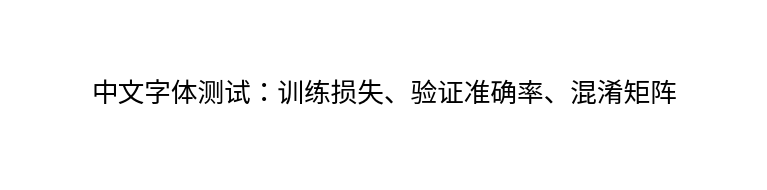

In [14]:
# ==========================================
# 6.2.2 AutoDL中文字体修复
# 只修复Matplotlib字体，不会重新训练模型
# ==========================================

import subprocess
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties


def find_chinese_font_file():
    """
    在Linux服务器常见字体目录中寻找中文字体。
    """

    preferred_paths = [
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc",
        "/usr/share/fonts/truetype/arphic/uming.ttc",
        "/usr/share/fonts/truetype/arphic/ukai.ttc"
    ]

    for font_path in preferred_paths:

        font_path = Path(
            font_path
        )

        if font_path.is_file():

            return font_path

    search_directories = [
        Path(
            "/usr/share/fonts"
        ),
        Path(
            "/usr/local/share/fonts"
        ),
        Path.home()
        / ".fonts"
    ]

    font_keywords = [
        "notosanscjk",
        "sourcehan",
        "wqy",
        "microhei",
        "zenhei",
        "simhei",
        "yahei",
        "uming",
        "ukai"
    ]

    for directory in search_directories:

        if not directory.exists():
            continue

        for font_path in directory.rglob(
            "*"
        ):

            if (
                font_path.is_file()
                and font_path.suffix.lower()
                in {
                    ".ttf",
                    ".otf",
                    ".ttc"
                }
            ):

                lower_name = (
                    font_path.name.lower()
                )

                if any(
                    keyword in lower_name
                    for keyword
                    in font_keywords
                ):

                    return font_path

    return None


def refresh_matplotlib_font_cache():
    """
    删除旧字体缓存并重新扫描字体。
    """

    cache_directory = Path(
        matplotlib.get_cachedir()
    )

    for cache_file in cache_directory.glob(
        "fontlist-v*.json"
    ):

        try:

            cache_file.unlink()

        except OSError:

            pass

    font_manager._load_fontmanager(
        try_read_cache=False
    )


CHINESE_FONT_PATH = (
    find_chinese_font_file()
)


# 服务器没有中文字体时自动安装Noto CJK
if CHINESE_FONT_PATH is None:

    print(
        "当前服务器没有检测到中文字体，"
        "开始安装 fonts-noto-cjk……"
    )

    subprocess.run(
        [
            "apt-get",
            "update",
            "-qq"
        ],
        check=True
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "fonts-noto-cjk"
        ],
        check=True
    )

    subprocess.run(
        [
            "fc-cache",
            "-f"
        ],
        check=False
    )

    refresh_matplotlib_font_cache()

    CHINESE_FONT_PATH = (
        find_chinese_font_file()
    )


if CHINESE_FONT_PATH is None:

    raise RuntimeError(
        "中文字体安装完成后仍未找到字体文件。"
    )


# 显式将字体加入当前Matplotlib进程
font_manager.fontManager.addfont(
    str(
        CHINESE_FONT_PATH
    )
)


CHINESE_FONT_PROPERTY = FontProperties(
    fname=str(
        CHINESE_FONT_PATH
    )
)


CHINESE_FONT_NAME = (
    CHINESE_FONT_PROPERTY
    .get_name()
)


plt.rcParams[
    "font.family"
] = CHINESE_FONT_NAME

plt.rcParams[
    "font.sans-serif"
] = [
    CHINESE_FONT_NAME
]

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300


print(
    "中文字体配置成功。"
)

print(
    f"字体名称：{CHINESE_FONT_NAME}"
)

print(
    f"字体文件：{CHINESE_FONT_PATH}"
)


# 中文显示测试
test_figure, test_axis = plt.subplots(
    figsize=(
        8,
        1.8
    )
)

test_axis.text(
    0.5,
    0.5,
    "中文字体测试：训练损失、验证准确率、混淆矩阵",
    ha="center",
    va="center",
    fontsize=16,
    fontproperties=(
        CHINESE_FONT_PROPERTY
    )
)

test_axis.axis(
    "off"
)

plt.show()

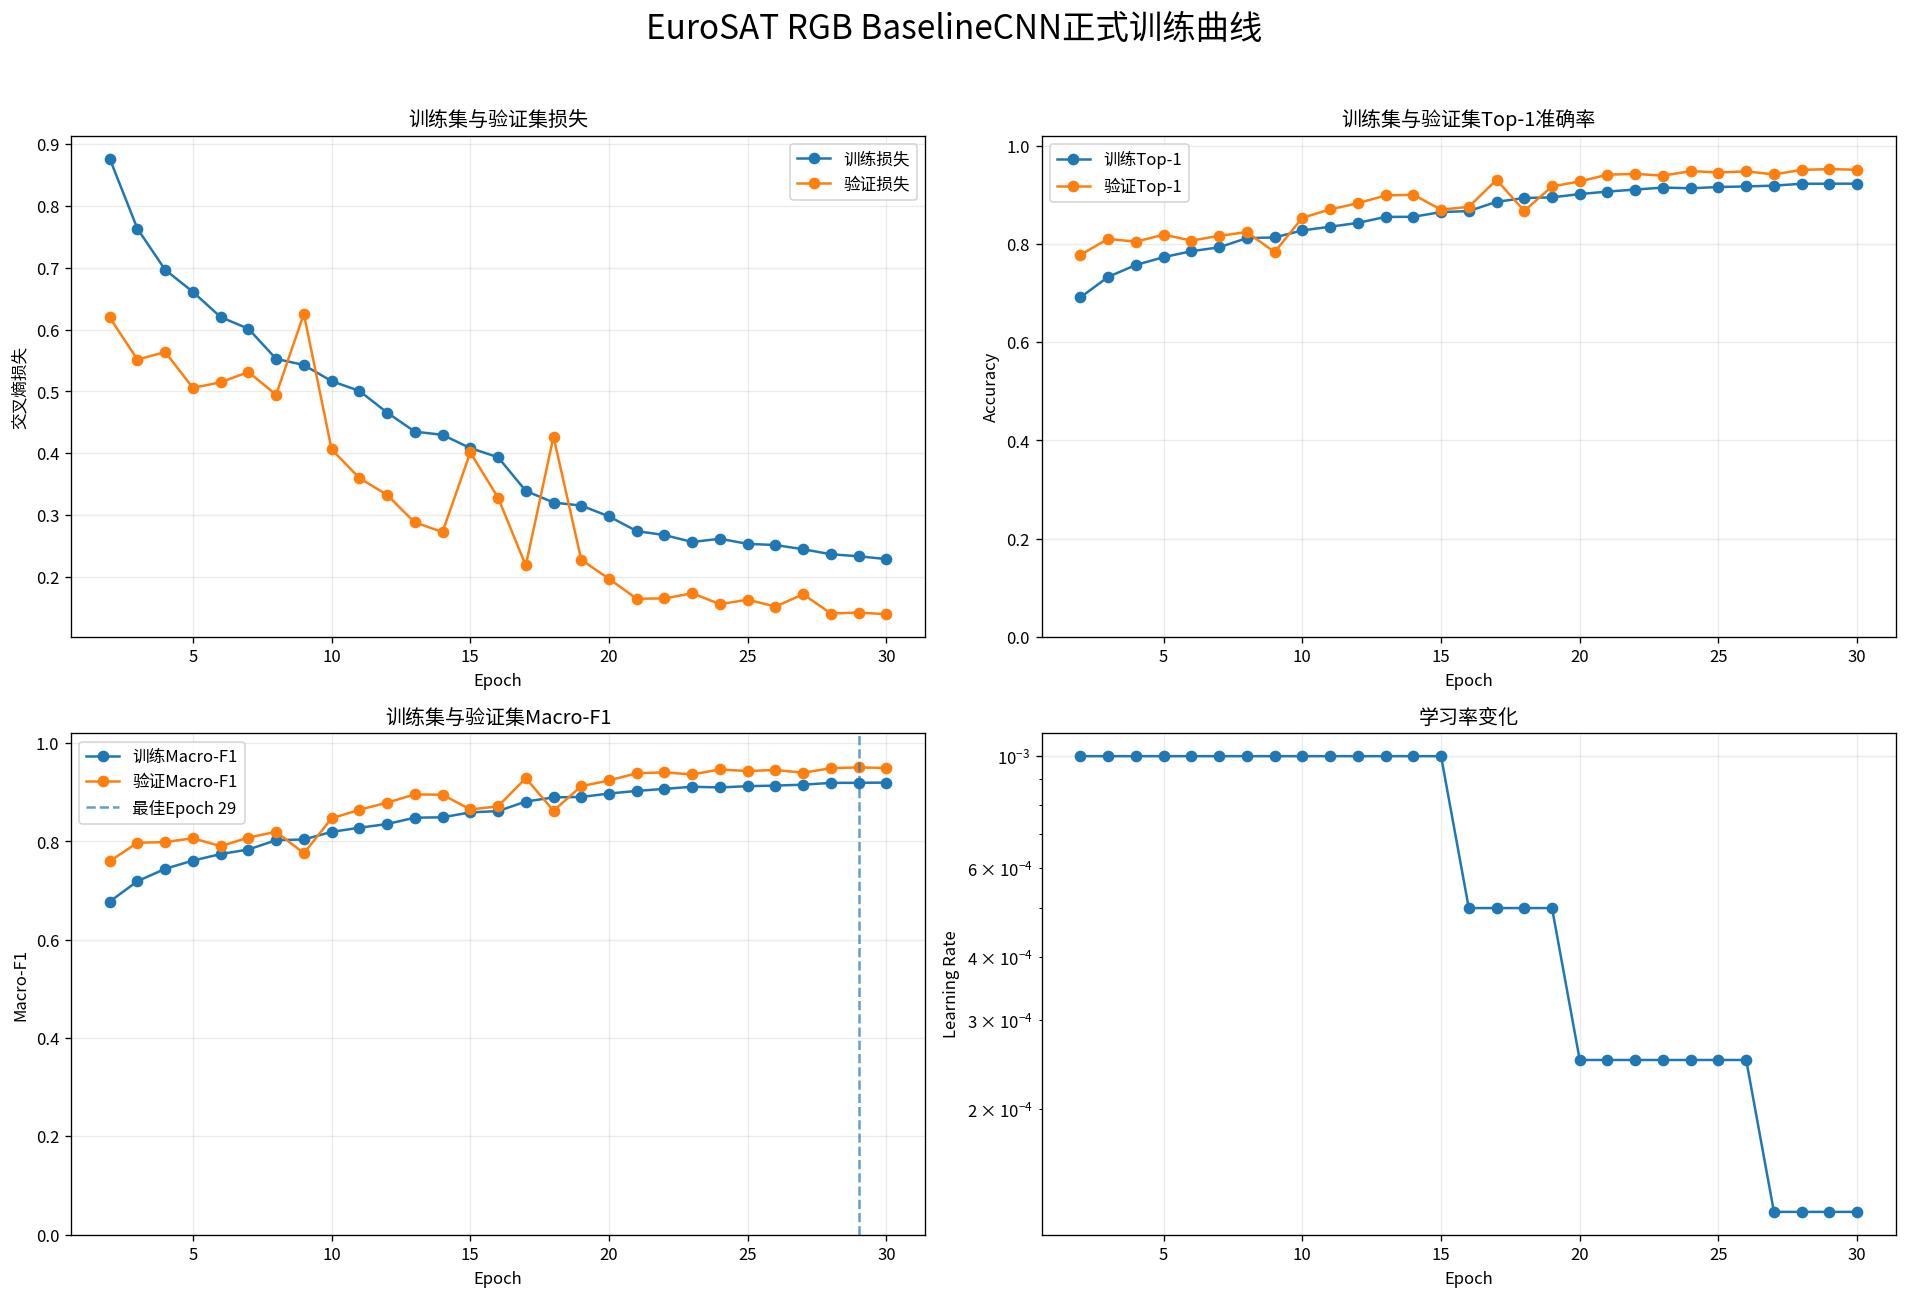

训练历史最佳记录：


,轮次,训练损失,验证损失,训练Top-1准确率,验证Top-1准确率,训练Top-3准确率,验证Top-3准确率,训练Macro-Precision,验证Macro-Precision,训练Macro-Recall,验证Macro-Recall,训练Macro-F1,验证Macro-F1,训练Weighted-F1,验证Weighted-F1,本轮初始学习率,本轮结束学习率,本轮耗时_秒,是否最佳轮次,连续未提升轮数
27,29,0.233644,0.14274,0.922434,0.952099,0.99381,0.997037,0.919461,0.951513,0.919533,0.950333,0.91947,0.950705,0.922309,0.951926,0.000125,0.000125,25.556163,True,0


In [15]:
# ==========================================
# 6.2.2 训练历史与收敛曲线
# ==========================================

if not TRAINING_HISTORY_PATH.exists():

    raise FileNotFoundError(
        "尚未生成训练历史文件，"
        "请先运行正式训练Cell。"
    )


training_history_df = pd.read_csv(
    TRAINING_HISTORY_PATH,
    encoding="utf-8-sig"
)


if training_history_df.empty:

    raise RuntimeError(
        "训练历史为空。"
    )


best_history_row = (
    training_history_df
    .sort_values(
        "验证Macro-F1",
        ascending=False
    )
    .iloc[
        0
    ]
)


figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(
        16,
        11
    )
)


# ------------------------------
# 损失曲线
# ------------------------------
axes[
    0,
    0
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "训练损失"
    ],
    marker="o",
    label="训练损失"
)

axes[
    0,
    0
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "验证损失"
    ],
    marker="o",
    label="验证损失"
)

axes[
    0,
    0
].set_title(
    "训练集与验证集损失"
)

axes[
    0,
    0
].set_xlabel(
    "Epoch"
)

axes[
    0,
    0
].set_ylabel(
    "交叉熵损失"
)

axes[
    0,
    0
].legend()

axes[
    0,
    0
].grid(
    alpha=0.25
)


# ------------------------------
# Top-1准确率
# ------------------------------
axes[
    0,
    1
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "训练Top-1准确率"
    ],
    marker="o",
    label="训练Top-1"
)

axes[
    0,
    1
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "验证Top-1准确率"
    ],
    marker="o",
    label="验证Top-1"
)

axes[
    0,
    1
].set_title(
    "训练集与验证集Top-1准确率"
)

axes[
    0,
    1
].set_xlabel(
    "Epoch"
)

axes[
    0,
    1
].set_ylabel(
    "Accuracy"
)

axes[
    0,
    1
].set_ylim(
    0,
    1.02
)

axes[
    0,
    1
].legend()

axes[
    0,
    1
].grid(
    alpha=0.25
)


# ------------------------------
# Macro-F1
# ------------------------------
axes[
    1,
    0
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "训练Macro-F1"
    ],
    marker="o",
    label="训练Macro-F1"
)

axes[
    1,
    0
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "验证Macro-F1"
    ],
    marker="o",
    label="验证Macro-F1"
)

axes[
    1,
    0
].axvline(
    x=int(
        best_history_row[
            "轮次"
        ]
    ),
    linestyle="--",
    alpha=0.7,
    label=(
        "最佳Epoch "
        f"{int(best_history_row['轮次'])}"
    )
)

axes[
    1,
    0
].set_title(
    "训练集与验证集Macro-F1"
)

axes[
    1,
    0
].set_xlabel(
    "Epoch"
)

axes[
    1,
    0
].set_ylabel(
    "Macro-F1"
)

axes[
    1,
    0
].set_ylim(
    0,
    1.02
)

axes[
    1,
    0
].legend()

axes[
    1,
    0
].grid(
    alpha=0.25
)


# ------------------------------
# 学习率曲线
# ------------------------------
axes[
    1,
    1
].plot(
    training_history_df[
        "轮次"
    ],
    training_history_df[
        "本轮结束学习率"
    ],
    marker="o"
)

axes[
    1,
    1
].set_title(
    "学习率变化"
)

axes[
    1,
    1
].set_xlabel(
    "Epoch"
)

axes[
    1,
    1
].set_ylabel(
    "Learning Rate"
)

axes[
    1,
    1
].set_yscale(
    "log"
)

axes[
    1,
    1
].grid(
    alpha=0.25
)


figure.suptitle(
    "EuroSAT RGB BaselineCNN正式训练曲线",
    fontsize=20,
    fontweight="bold"
)

figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


training_curve_path = (
    STEP_OUTPUT_DIR
    / "08_BaselineCNN正式训练曲线.png"
)

figure.savefig(
    training_curve_path,
    bbox_inches="tight"
)

plt.show()


print(
    "训练历史最佳记录："
)

display(
    pd.DataFrame(
        [
            best_history_row
        ]
    )
)

#### 6.2.2.1 BaselineCNN训练收敛性分析

从训练曲线可以看出，BaselineCNN在30轮训练过程中整体保持稳定收敛。训练损失由训练初期的0.8764逐步下降至第30轮的0.2291，验证损失则由0.6197下降至0.1400，说明模型持续学习到了能够区分不同地物类别的有效视觉特征。

训练过程中，验证损失在第9轮、第15轮和第18轮附近出现了短暂波动，但随后均能恢复并继续下降。该现象主要与训练集随机翻转、旋转和颜色扰动等数据增强操作有关，同时也受到小批量随机优化的影响，并不表示模型发生了发散。进入训练后期后，验证损失稳定维持在较低水平，模型收敛状态良好。

在分类准确率方面，训练集Top-1准确率由69.11%逐步提升至92.25%，验证集Top-1准确率则由77.78%提升至约95%。验证集准确率在多数轮次中高于训练集准确率，主要是因为训练阶段启用了随机数据增强和Dropout，使训练样本难度更高；验证阶段关闭Dropout并仅进行确定性预处理，因此验证结果更加稳定。该现象属于正常的正则化效果，不能直接解释为数据泄漏或评价异常。

Macro-F1曲线与Top-1准确率的变化趋势基本一致。训练集Macro-F1由67.76%提升至91.98%，验证集Macro-F1最终接近95%，说明模型不仅提升了总体准确率，也对不同样本规模的类别保持了较均衡的识别能力。

学习率调度器根据验证集Macro-F1的停滞情况逐步降低学习率：初始学习率为1×10⁻³，第16轮后降至5×10⁻⁴，第20轮后降至2.5×10⁻⁴，第27轮后进一步降至1.25×10⁻⁴。每次学习率下降后，验证指标均获得进一步提升，说明ReduceLROnPlateau调度策略正常生效，并帮助模型在训练后期进行更细致的参数优化。

综合训练损失、验证损失、准确率和Macro-F1曲线可知，模型没有出现持续性的验证性能下降，训练后期也未表现出明显过拟合。BaselineCNN已在当前数据集上实现稳定收敛，可作为后续迁移学习模型的基准对照。

验证:   0%|          | 0/127 [00:00<?, ?it/s]

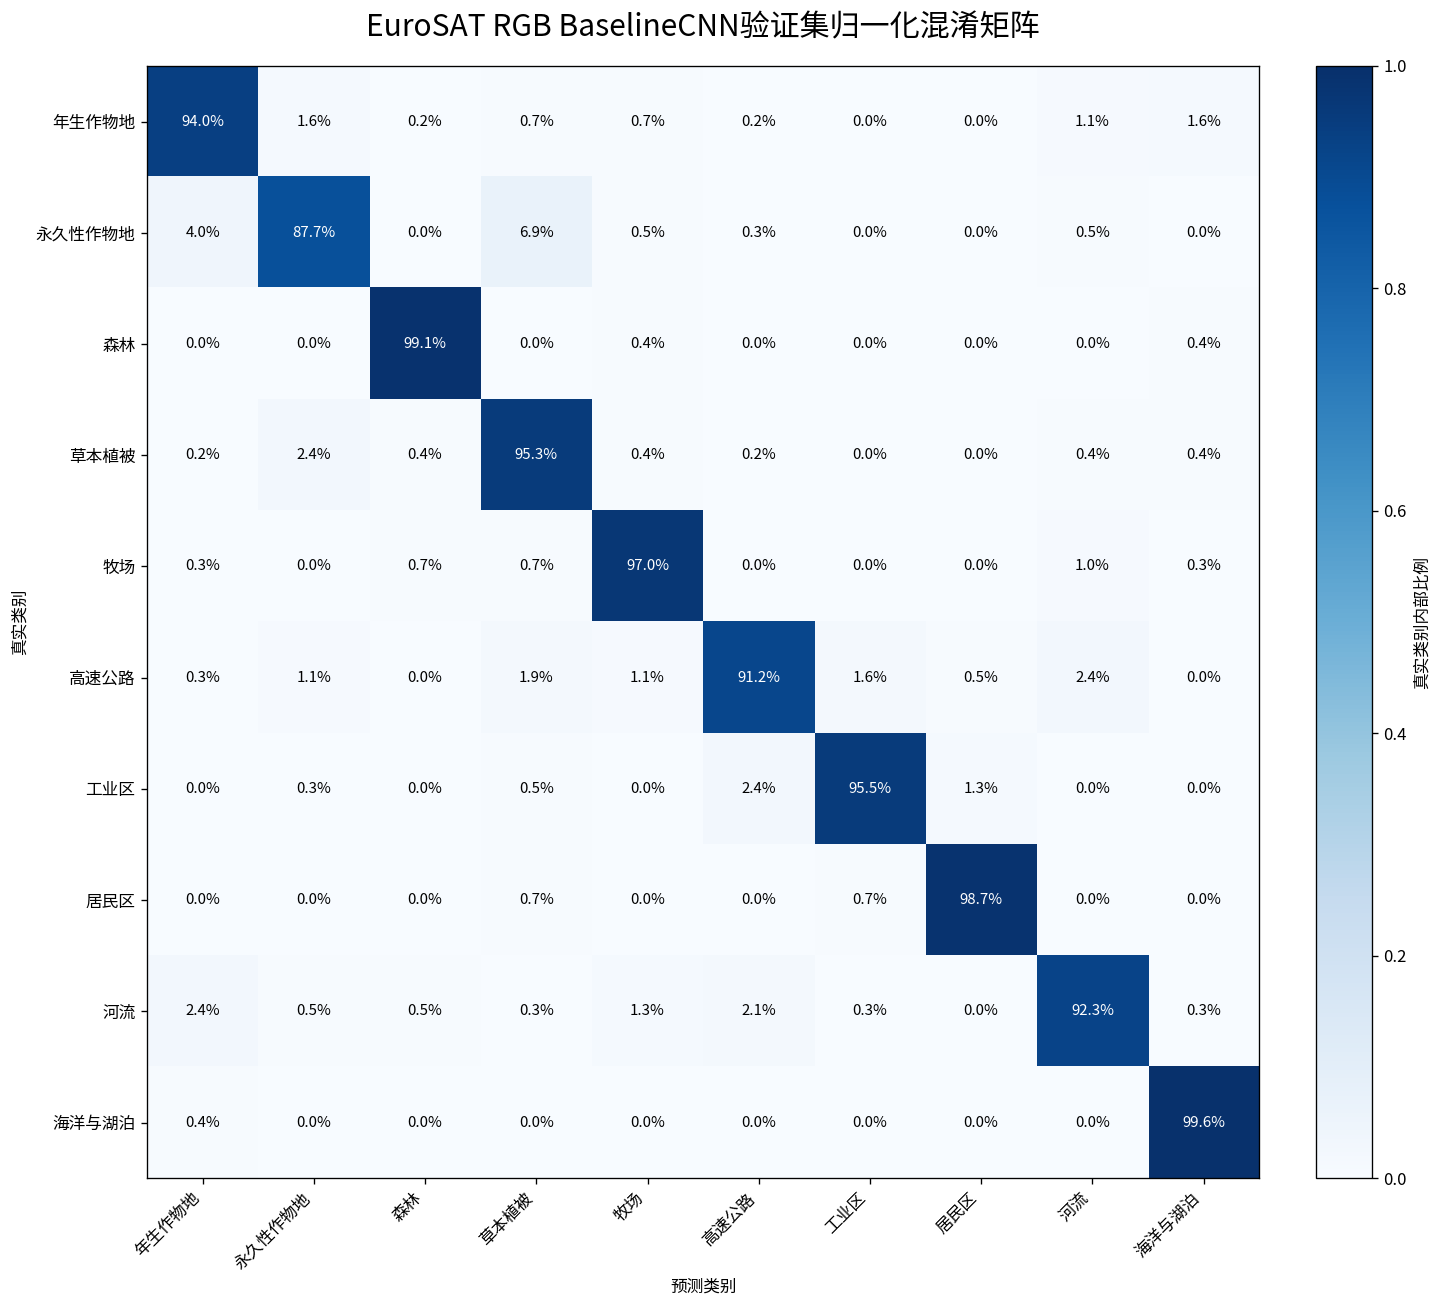

最佳模型总体指标：


,评价指标,指标结果
0,验证损失,0.142740
1,Top-1 Accuracy,0.952099
2,Top-3 Accuracy,0.997037
3,Macro Precision,0.951513
4,Macro Recall,0.950333
5,Macro F1,0.950705
6,Weighted F1,0.951926
7,最佳模型轮次,29.000000



最佳模型各类别指标：


,类别索引,类别中文名称,类别英文名称,Precision,Recall,F1,样本数量
0,0,年生作物地,AnnualCrop,0.935841,0.940000,0.937916,450
1,1,永久性作物地,PermanentCrop,0.929379,0.877333,0.902606,375
2,2,森林,Forest,0.984547,0.991111,0.987818,450
3,3,草本植被,HerbaceousVegetation,0.906977,0.953333,0.929577,450
4,4,牧场,Pasture,0.941748,0.970000,0.955665,300
5,5,高速公路,Highway,0.944751,0.912000,0.928087,375
6,6,工业区,Industrial,0.972826,0.954667,0.963661,375
7,7,居民区,Residential,0.984479,0.986667,0.985572,450
8,8,河流,River,0.942779,0.922667,0.932615,375
9,9,海洋与湖泊,SeaLake,0.971800,0.995556,0.983535,450


In [16]:
# ==========================================
# 6.2.2 最佳模型验证与混淆矩阵
# ==========================================

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        "未找到最佳模型文件，"
        "请先完成正式训练。"
    )


best_checkpoint = safe_torch_load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    DEVICE
)


best_val_metrics = evaluate_one_epoch(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    epoch_index=None
)


best_confusion_matrix = (
    best_val_metrics[
        "confusion_matrix"
    ]
)


row_sum = best_confusion_matrix.sum(
    axis=1,
    keepdims=True
)


normalized_confusion_matrix = np.divide(
    best_confusion_matrix,
    row_sum,
    out=np.zeros_like(
        best_confusion_matrix,
        dtype=np.float64
    ),
    where=row_sum != 0
)


# ------------------------------
# 总体指标
# ------------------------------
best_validation_summary_df = pd.DataFrame({
    "评价指标": [
        "验证损失",
        "Top-1 Accuracy",
        "Top-3 Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "最佳模型轮次"
    ],
    "指标结果": [
        best_val_metrics[
            "loss"
        ],
        best_val_metrics[
            "top1_accuracy"
        ],
        best_val_metrics[
            "top3_accuracy"
        ],
        best_val_metrics[
            "macro_precision"
        ],
        best_val_metrics[
            "macro_recall"
        ],
        best_val_metrics[
            "macro_f1"
        ],
        best_val_metrics[
            "weighted_f1"
        ],
        int(
            best_checkpoint[
                "epoch"
            ]
        )
    ]
})


best_validation_summary_path = (
    STEP_OUTPUT_DIR
    / "09_BaselineCNN最佳模型验证指标.csv"
)

best_validation_summary_df.to_csv(
    best_validation_summary_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------
# 各类别指标
# ------------------------------
per_class_metrics_df = pd.DataFrame({
    "类别索引": list(
        range(
            NUM_CLASSES
        )
    ),
    "类别中文名称": (
        CLASS_NAMES_CN
    ),
    "类别英文名称": (
        CLASS_NAMES_EN
    ),
    "Precision": (
        best_val_metrics[
            "precision_per_class"
        ]
    ),
    "Recall": (
        best_val_metrics[
            "recall_per_class"
        ]
    ),
    "F1": (
        best_val_metrics[
            "f1_per_class"
        ]
    ),
    "样本数量": (
        best_val_metrics[
            "support_per_class"
        ]
        .astype(
            int
        )
    )
})


per_class_metrics_path = (
    STEP_OUTPUT_DIR
    / "10_BaselineCNN各类别验证指标.csv"
)

per_class_metrics_df.to_csv(
    per_class_metrics_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------
# 保存混淆矩阵
# ------------------------------
confusion_matrix_df = pd.DataFrame(
    best_confusion_matrix,
    index=CLASS_NAMES_EN,
    columns=CLASS_NAMES_EN
)

confusion_matrix_df.to_csv(
    STEP_OUTPUT_DIR
    / "11_BaselineCNN验证集混淆矩阵.csv",
    encoding="utf-8-sig"
)


# ------------------------------
# 混淆矩阵可视化
# ------------------------------
figure, axis = plt.subplots(
    figsize=(
        13,
        11
    )
)


image = axis.imshow(
    normalized_confusion_matrix,
    cmap="Blues",
    vmin=0,
    vmax=1
)


axis.set_title(
    "EuroSAT RGB BaselineCNN验证集归一化混淆矩阵",
    fontsize=18,
    fontweight="bold",
    pad=18
)

axis.set_xlabel(
    "预测类别"
)

axis.set_ylabel(
    "真实类别"
)


axis.set_xticks(
    np.arange(
        NUM_CLASSES
    )
)

axis.set_yticks(
    np.arange(
        NUM_CLASSES
    )
)

axis.set_xticklabels(
    CLASS_NAMES_CN,
    rotation=45,
    ha="right"
)

axis.set_yticklabels(
    CLASS_NAMES_CN
)


for row_index in range(
    NUM_CLASSES
):

    for column_index in range(
        NUM_CLASSES
    ):

        cell_value = (
            normalized_confusion_matrix[
                row_index,
                column_index
            ]
        )

        text_color = (
            "white"
            if cell_value > 0.50
            else "black"
        )

        axis.text(
            column_index,
            row_index,
            f"{cell_value:.1%}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )


colorbar = figure.colorbar(
    image,
    ax=axis,
    fraction=0.046,
    pad=0.04
)

colorbar.set_label(
    "真实类别内部比例"
)


figure.tight_layout()


confusion_matrix_plot_path = (
    STEP_OUTPUT_DIR
    / "12_BaselineCNN验证集归一化混淆矩阵.png"
)

figure.savefig(
    confusion_matrix_plot_path,
    bbox_inches="tight"
)

plt.show()


print(
    "最佳模型总体指标："
)

display(
    best_validation_summary_df
)


print(
    "\n最佳模型各类别指标："
)

display(
    per_class_metrics_df
)

#### 6.2.2.2 最佳模型验证结果分析

本实验以验证集Macro-F1作为最佳模型选择指标，最终最佳模型出现在第29轮。该轮验证损失为0.1427，Top-1准确率为95.21%，Top-3准确率为99.70%，Macro Precision为95.15%，Macro Recall为95.03%，Macro-F1为95.07%，Weighted-F1为95.19%。

Top-1准确率表明，模型在4,050张验证图像中正确分类了3,856张样本。Top-3准确率达到99.70%，说明即使模型的首选预测出现错误，真实类别在绝大多数情况下仍位于前三个候选类别中，反映出模型已经学习到较清晰的类别特征边界。

Macro-F1与Weighted-F1分别为95.07%和95.19%，二者差异仅约0.12个百分点。这说明类别样本数量差异并未明显影响模型总体评价结果，模型在高样本类别与低样本类别之间保持了较好的性能平衡。

从各类别结果来看，模型对海洋与湖泊、森林和居民区的识别效果最好。其中海洋与湖泊的召回率达到99.56%，森林召回率达到99.11%，居民区召回率达到98.67%。这些类别在颜色、纹理或空间结构方面具有较明显的视觉特征，因此较容易被卷积网络稳定识别。

牧场和工业区同样表现良好，其F1值分别达到95.57%和96.37%。牧场具有较连续的绿色地表纹理，工业区则通常包含规则的大型建筑和高亮屋顶，模型能够有效捕捉这些局部与整体结构特征。

相对而言，永久性作物地是识别难度最高的类别，其召回率为87.73%，F1值为90.26%。混淆矩阵显示，永久性作物地有6.93%的样本被预测为草本植被，另有4.00%的样本被预测为年生作物地。三类地物均具有农田或植被纹理，在低分辨率遥感图像中容易出现颜色和空间结构相似的问题。

高速公路的召回率为91.20%，部分样本被误判为河流、草本植被或工业区。其中2.40%的高速公路样本被识别为河流，1.87%被识别为草本植被，1.60%被识别为工业区。这主要是因为高速公路和河流都可能表现为细长、连续的线状结构，而高速公路周边的植被和建筑又会干扰道路主体特征。

河流类别的召回率为92.27%，其主要混淆方向为年生作物地和高速公路。部分河流样本中水体所占比例较小，同时包含较大面积农田或道路结构，因此模型可能优先关注周围背景而非河流本身。

总体而言，混淆矩阵的高值主要集中在主对角线上，除永久性作物地、高速公路和河流外，其余类别的召回率均超过94%。结果说明BaselineCNN已经具备较强的遥感场景分类能力，但在视觉纹理接近的农业类别以及具有相似线状结构的道路与河流之间仍存在一定混淆。

In [17]:
# ==========================================
# 6.2.2 训练结果汇总与文件归档
# ==========================================

def calculate_file_sha256(
    file_path
):
    """
    计算模型文件SHA256，用于结果完整性检查。
    """

    sha256_hash = hashlib.sha256()


    with open(
        file_path,
        "rb"
    ) as file:

        for byte_block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b""
        ):

            sha256_hash.update(
                byte_block
            )


    return sha256_hash.hexdigest()


best_model_size_mb = (
    BEST_MODEL_PATH.stat().st_size
    / 1024 ** 2
)

latest_model_size_mb = (
    LATEST_MODEL_PATH.stat().st_size
    / 1024 ** 2
)

best_model_sha256 = (
    calculate_file_sha256(
        BEST_MODEL_PATH
    )
)


gpu_peak_memory_gb = (
    torch.cuda.max_memory_allocated(
        DEVICE
    )
    / 1024 ** 3
)


final_summary = {
    "步骤": (
        "6.2.2_BaselineCNN正式训练"
    ),
    "模型名称": (
        "BaselineCNN"
    ),
    "GPU型号": (
        GPU_NAME
    ),
    "PyTorch版本": (
        torch.__version__
    ),
    "PyTorch CUDA版本": (
        PYTORCH_CUDA_VERSION
    ),
    "训练集样本数": int(
        len(
            train_dataset
        )
    ),
    "验证集样本数": int(
        len(
            val_dataset
        )
    ),
    "批次大小": int(
        BATCH_SIZE
    ),
    "模型总参数量": int(
        total_parameter_count
    ),
    "实际完成轮数": int(
        training_history_df[
            "轮次"
        ].max()
    ),
    "最佳轮次": int(
        best_checkpoint[
            "epoch"
        ]
    ),
    "最佳验证损失": float(
        best_val_metrics[
            "loss"
        ]
    ),
    "最佳验证Top-1准确率": float(
        best_val_metrics[
            "top1_accuracy"
        ]
    ),
    "最佳验证Top-3准确率": float(
        best_val_metrics[
            "top3_accuracy"
        ]
    ),
    "最佳验证Macro-Precision": float(
        best_val_metrics[
            "macro_precision"
        ]
    ),
    "最佳验证Macro-Recall": float(
        best_val_metrics[
            "macro_recall"
        ]
    ),
    "最佳验证Macro-F1": float(
        best_val_metrics[
            "macro_f1"
        ]
    ),
    "最佳验证Weighted-F1": float(
        best_val_metrics[
            "weighted_f1"
        ]
    ),
    "GPU峰值参数与张量显存_GB": float(
        gpu_peak_memory_gb
    ),
    "最佳模型大小_MB": float(
        best_model_size_mb
    ),
    "最近模型大小_MB": float(
        latest_model_size_mb
    ),
    "最佳模型SHA256": (
        best_model_sha256
    ),
    "最佳模型路径": str(
        BEST_MODEL_PATH
    ),
    "最近模型路径": str(
        LATEST_MODEL_PATH
    ),
    "训练历史路径": str(
        TRAINING_HISTORY_PATH
    ),
    "结果目录": str(
        STEP_OUTPUT_DIR
    ),
    "完成时间": (
        datetime.now()
        .isoformat(
            timespec="seconds"
        )
    )
}


final_summary_path = (
    STEP_OUTPUT_DIR
    / "13_BaselineCNN正式训练结果汇总.json"
)

with open(
    final_summary_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_summary,
        file,
        ensure_ascii=False,
        indent=4
    )


final_summary_df = pd.DataFrame({
    "汇总项目": list(
        final_summary.keys()
    ),
    "汇总结果": list(
        final_summary.values()
    )
})


final_summary_csv_path = (
    STEP_OUTPUT_DIR
    / "14_BaselineCNN正式训练结果汇总.csv"
)

final_summary_df.to_csv(
    final_summary_csv_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "BaselineCNN正式训练结果归档完成。"
)

display(
    final_summary_df
)


print(
    "\n需要下载保存的重要文件："
)

print(
    f"1. 最佳模型："
    f"{BEST_MODEL_PATH}"
)

print(
    f"2. 最近检查点："
    f"{LATEST_MODEL_PATH}"
)

print(
    f"3. 训练历史："
    f"{TRAINING_HISTORY_PATH}"
)

print(
    f"4. 结果目录："
    f"{STEP_OUTPUT_DIR}"
)

BaselineCNN正式训练结果归档完成。


,汇总项目,汇总结果
0,步骤,6.2.2_BaselineCNN正式训练
1,模型名称,BaselineCNN
2,GPU型号,NVIDIA GeForce RTX 4090 D
3,PyTorch版本,2.5.1+cu124
4,PyTorch CUDA版本,12.4
5,训练集样本数,18900
6,验证集样本数,4050
7,批次大小,32
8,模型总参数量,391946
9,实际完成轮数,30



需要下载保存的重要文件：
1. 最佳模型：/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_best.pt
2. 最近检查点：/root/autodl-tmp/.autodl/课设/models/baseline_cnn/BaselineCNN_latest.pt
3. 训练历史：/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练/07_BaselineCNN训练历史.csv
4. 结果目录：/root/autodl-tmp/.autodl/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练


#### 6.2.2.3 BaselineCNN正式训练小结

本节完成了BaselineCNN在EuroSAT RGB数据集上的正式训练与验证。模型采用四个连续卷积块进行逐层特征提取，通过最大池化逐步降低空间分辨率，并利用全局平均池化和Dropout完成特征压缩与正则化，最终输出10类地物场景的分类结果。

模型共包含391,946个可训练参数，在保持较低参数规模的同时，最佳验证Top-1准确率达到95.21%，Macro-F1达到95.07%，说明该网络能够有效学习EuroSAT RGB图像中的颜色、纹理、边缘和空间结构特征。

训练曲线显示模型收敛稳定，学习率衰减策略能够在验证指标停滞时进一步细化参数更新，训练后期未出现明显过拟合。验证集混淆矩阵表明，模型对森林、居民区、海洋与湖泊等视觉特征明显的类别具有较高识别能力，而永久性作物地、草本植被、年生作物地以及高速公路、河流之间仍存在一定视觉混淆。

因此，本模型可以作为本项目的随机初始化基准模型。后续将使用相同的数据划分、图像预处理和评价指标训练ResNet18迁移学习模型，并从分类性能、收敛速度、类别识别能力和模型复杂度等方面与BaselineCNN进行统一对比。